# Unfactorized attention model for synthetic datas 

In [29]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import seaborn as sns

In [30]:
run_id = "20251215_1334"

run_dir = f"../results/run_{run_id}/"
config_path = f"../results/run_{run_id}/config.csv"
base_path = f"../results/run_{run_id}/summary.csv"

plot_path = f"../results/run_{run_id}/plots/"
os.makedirs(plot_path, exist_ok=True)

In [31]:
# --- 1. Global Academic Style Configuration ---

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'figure.dpi': 300,
    'savefig.bbox': 'tight',
})

## 1. experiment config

In [32]:
# --- Read the CSV file ---
config = pd.read_csv(config_path)
print(f"⚙️ Config loaded ({len(config)} rows) from {config_path}")

# --- Quick preview ---
display(config)

⚙️ Config loaded (15 rows) from ../results/run_20251215_1334/config.csv


,alpha,D,L,rho,beta,lam,Delta_in,samples,T,learning_rate,norm_init,tol,N_test,base_dir
0,0.010000,100,2,1.0,1.0,0.0001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
1,0.080714,100,2,1.0,1.0,0.0001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
2,0.151429,100,2,1.0,1.0,0.0001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
3,0.222143,100,2,1.0,1.0,0.0001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
4,1.000000,100,2,1.0,1.0,0.0001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
5,0.292857,100,2,1.0,1.0,0.0001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
6,0.434286,100,2,1.0,1.0,0.0001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
7,0.363571,100,2,1.0,1.0,0.0001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
8,0.505000,100,2,1.0,1.0,0.0001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
9,0.575714,100,2,1.0,1.0,0.0001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...


## 2. Metric as function of $\alpha$ for different $\lambda$

✅ Summary loaded (60 rows) from ../results/run_20251215_1334/summary.csv


,alpha,alpha_idx,lam,rho,MSE_mean,MSE_std,label_err_mean,label_err_std,label_err_mean_noise,label_err_std_noise,train_data_mean,train_reg_mean,train_total_mean
0,0.010000,0,0.1000,1.0,0.013359,0.000613,0.415010,0.021907,0.470453,0.020873,0.001616,0.000395,0.002011
1,0.010000,0,0.0100,1.0,0.090693,0.010927,0.890675,0.025873,0.949556,0.024104,0.003927,0.000837,0.004764
2,0.010000,0,0.0010,1.0,0.423621,0.061515,1.064624,0.023089,1.122470,0.023283,0.004602,0.000420,0.005022
3,0.010000,0,0.0001,1.0,1.471646,1.247600,1.093826,0.077210,1.153388,0.075628,0.004541,0.000148,0.004689
4,0.080714,0,0.1000,1.0,0.009150,0.000070,0.258710,0.006294,0.323074,0.006708,0.000549,0.000209,0.000757


✅ Saved plot: ../results/run_20251215_1334/plots/MSE_vs_alpha.png


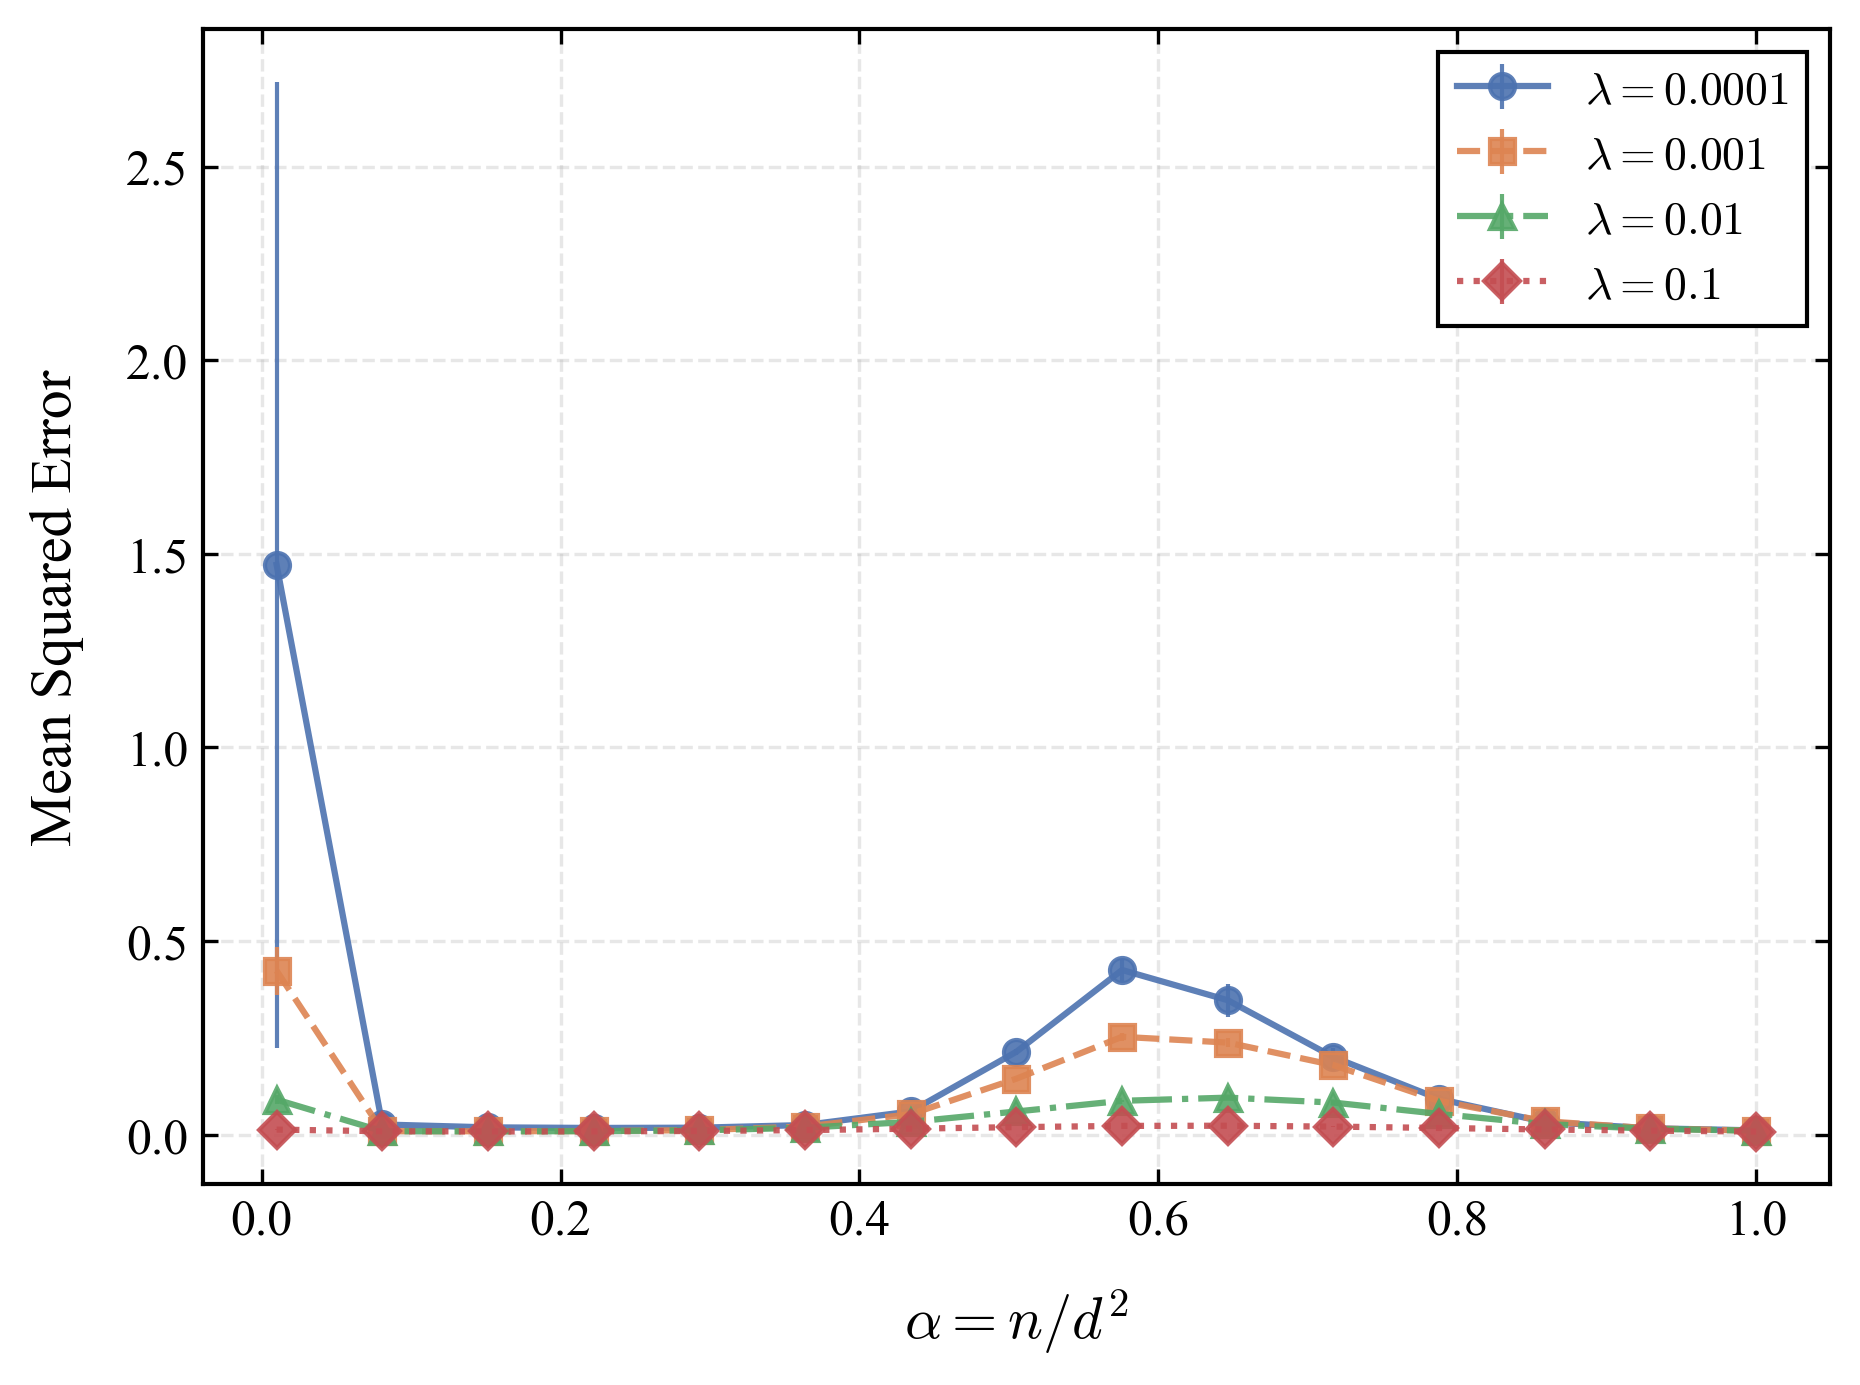

✅ Saved plot: ../results/run_20251215_1334/plots/LabelError_vs_alpha.png


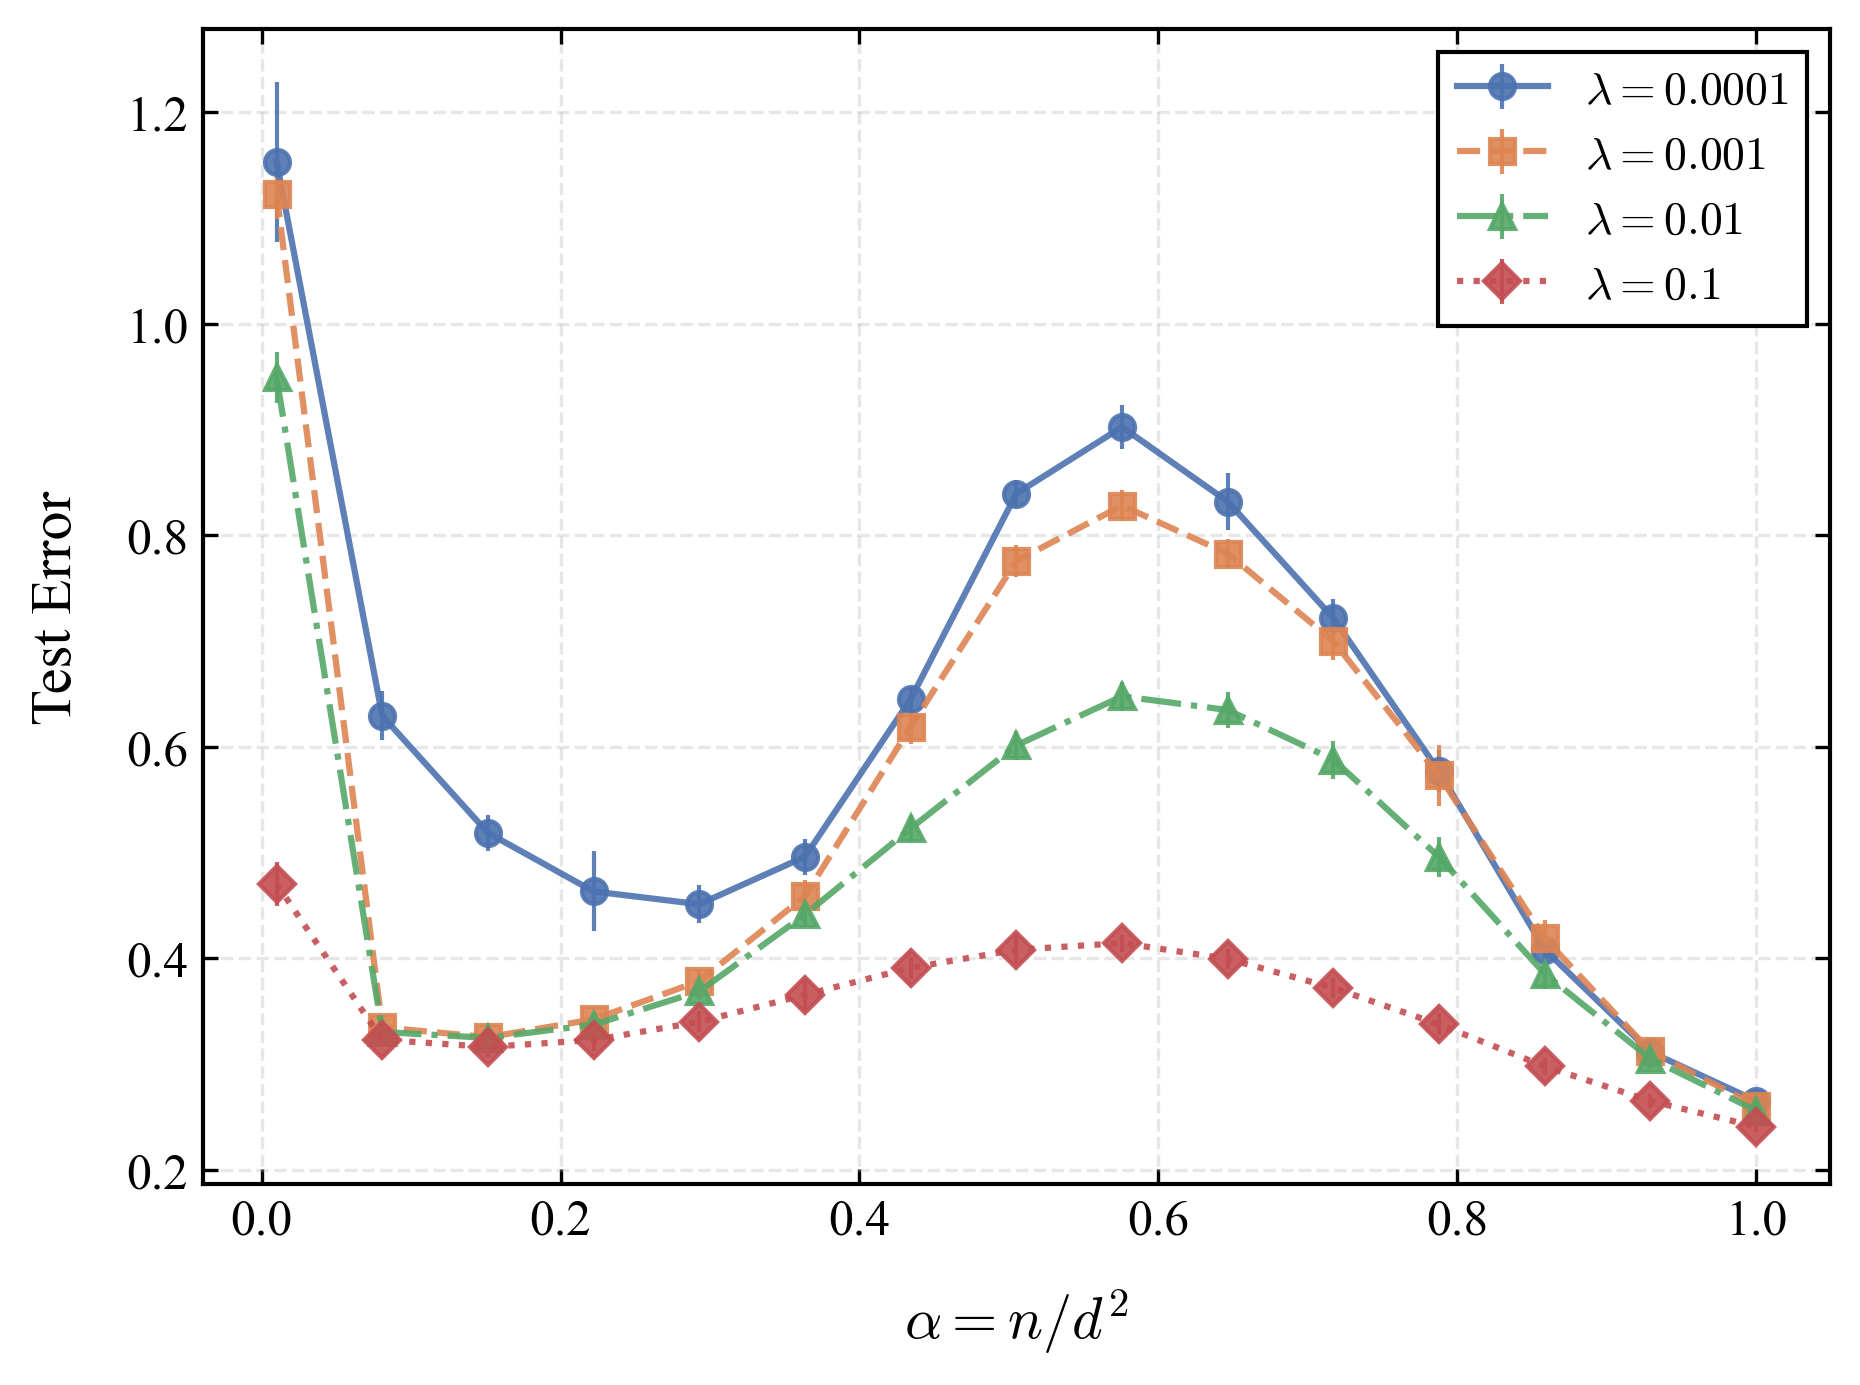

✅ Saved plot: ../results/run_20251215_1334/plots/TrainData_vs_alpha.png


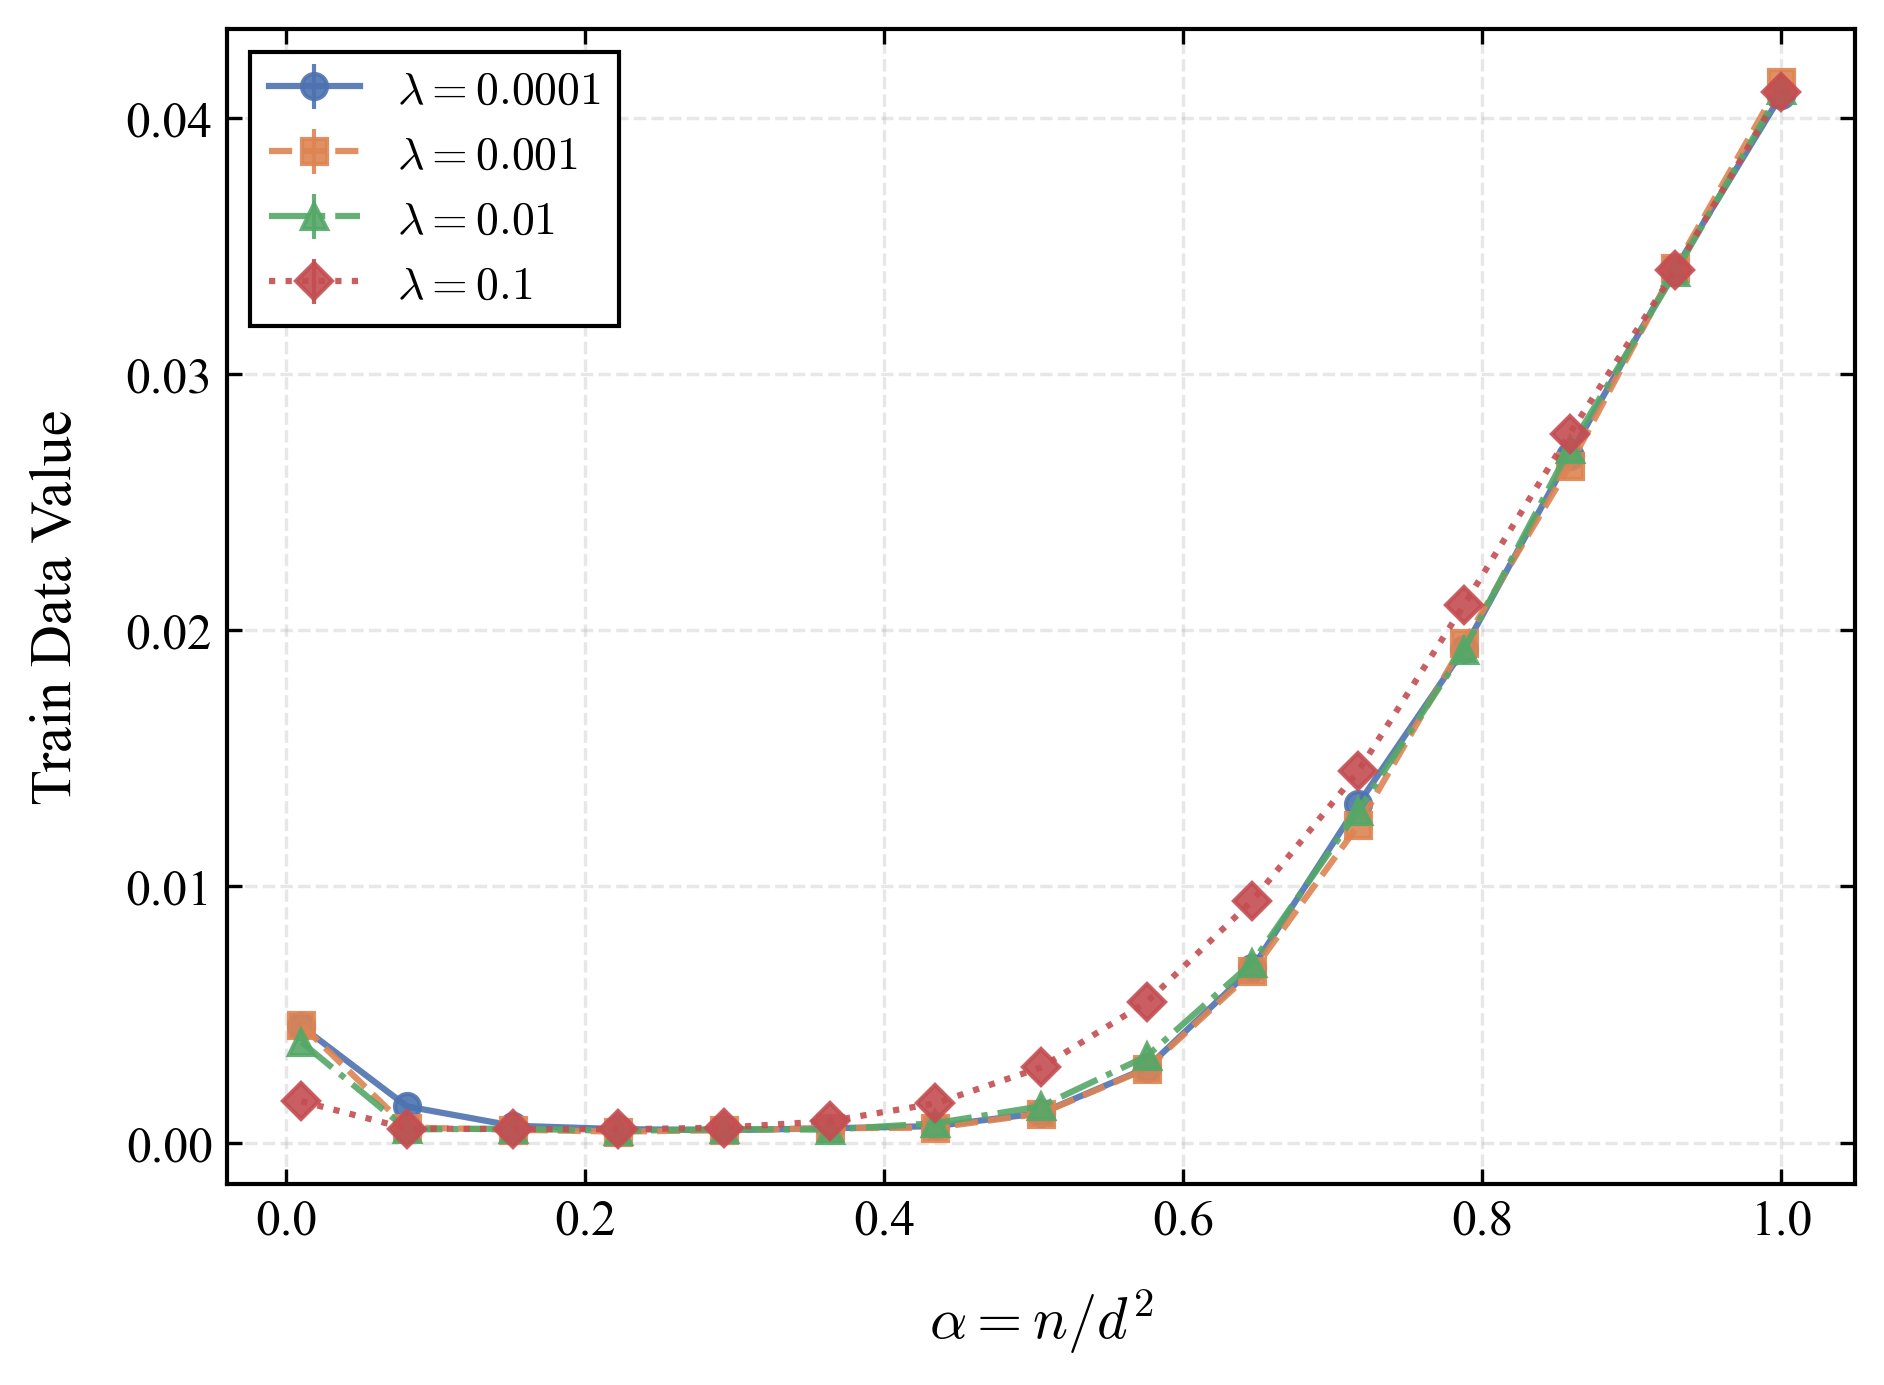

In [33]:
# --- Read the CSV file ---
df = pd.read_csv(base_path)
print(f"✅ Summary loaded ({len(df)} rows) from {base_path}")
display(df.head())

# --- Setup Markers & Colors ---
markers = ['o', 's', '^', 'D', 'v', '<', '>']
linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1))]
# If you haven't loaded df yet, make sure to load it before this step
# colors = sns.color_palette("deep", n_colors=len(df["lam"].unique())) 

# --- 2. The Reusable Plotting Function (Boxed) ---
def plot_academic_metric(df, y_col, y_err_col, ylabel, filename, plot_path):
    fig, ax = plt.subplots(figsize=(7, 5))
    
    unique_lams = sorted(df["lam"].unique())
    colors = sns.color_palette("deep", n_colors=len(unique_lams)) # Defined here to be safe
    
    for i, lam in enumerate(unique_lams):
        subset = df[df["lam"] == lam].sort_values("alpha")
        
        fmt_marker = markers[i % len(markers)]
        fmt_ls = linestyles[i % len(linestyles)]
        fmt_color = colors[i % len(colors)]
        
        ax.errorbar(
            subset["alpha"], 
            subset[y_col], 
            yerr=subset.get(y_err_col, 0),
            label=fr"$\lambda={lam}$",
            marker=fmt_marker,
            linestyle=fmt_ls,
            color=fmt_color,
            capsize=0,
            elinewidth=1,
            markeredgewidth=1,
            alpha=0.9
        )

    # Labeling
    ax.set_xlabel(r"$\alpha = n / d^2$", labelpad=10)
    ax.set_ylabel(ylabel, labelpad=10)
    
    # --- BOX STYLE SETTINGS ---
    # 1. Ensure grid is behind the plot
    ax.set_axisbelow(True) 
    
    # 2. Add ticks to Top and Right axes (inner direction is cleaner for boxes)
    ax.tick_params(direction='in', top=True, right=True, which='both')
    
    # 3. (Optional) Explicitly set spines to black if needed
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.0)
    
    # Legend
    ax.legend(frameon=True, fancybox=False, edgecolor='black', framealpha=1.0)
    
    # Save
    full_path = os.path.join(plot_path, filename)
    plt.savefig(full_path)
    print(f"✅ Saved plot: {full_path}")
    plt.show()

# --- 3. Run the plots ---

# MSE
plot_academic_metric(df, "MSE_mean", "MSE_std", "Mean Squared Error", "MSE_vs_alpha.png", plot_path)

# Label Error
plot_academic_metric(df, "label_err_mean_noise", "label_err_std_noise", "Test Error", "LabelError_vs_alpha.png", plot_path)

# Train Data
plot_academic_metric(df, "train_data_mean", "train_data_std", "Train Data Value", "TrainData_vs_alpha.png", plot_path)

## 3. Eigenvalue distributions per $\rho$

Found 15 S_runs files.

Processing ../results/run_20251215_1334/S_runs_0.pkl, containing 4 lambda indices...


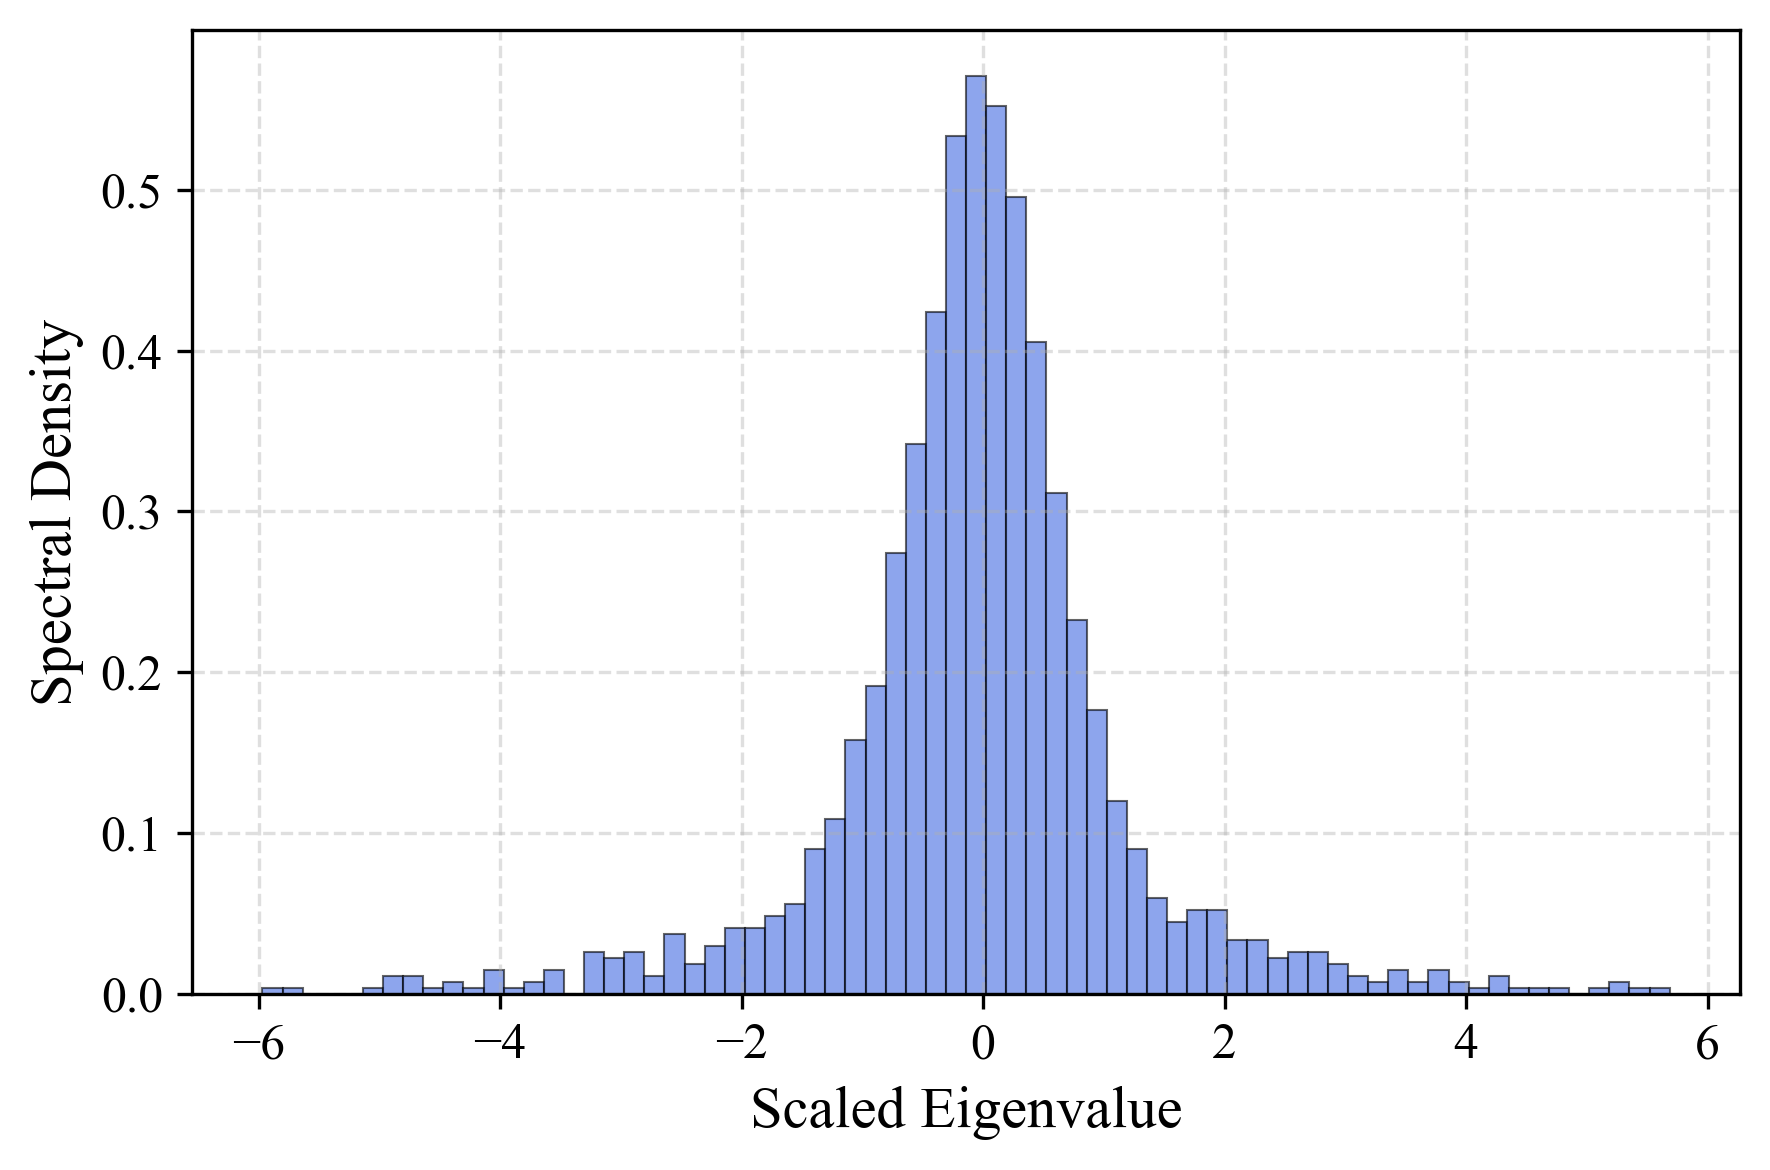


Processing ../results/run_20251215_1334/S_runs_1.pkl, containing 4 lambda indices...


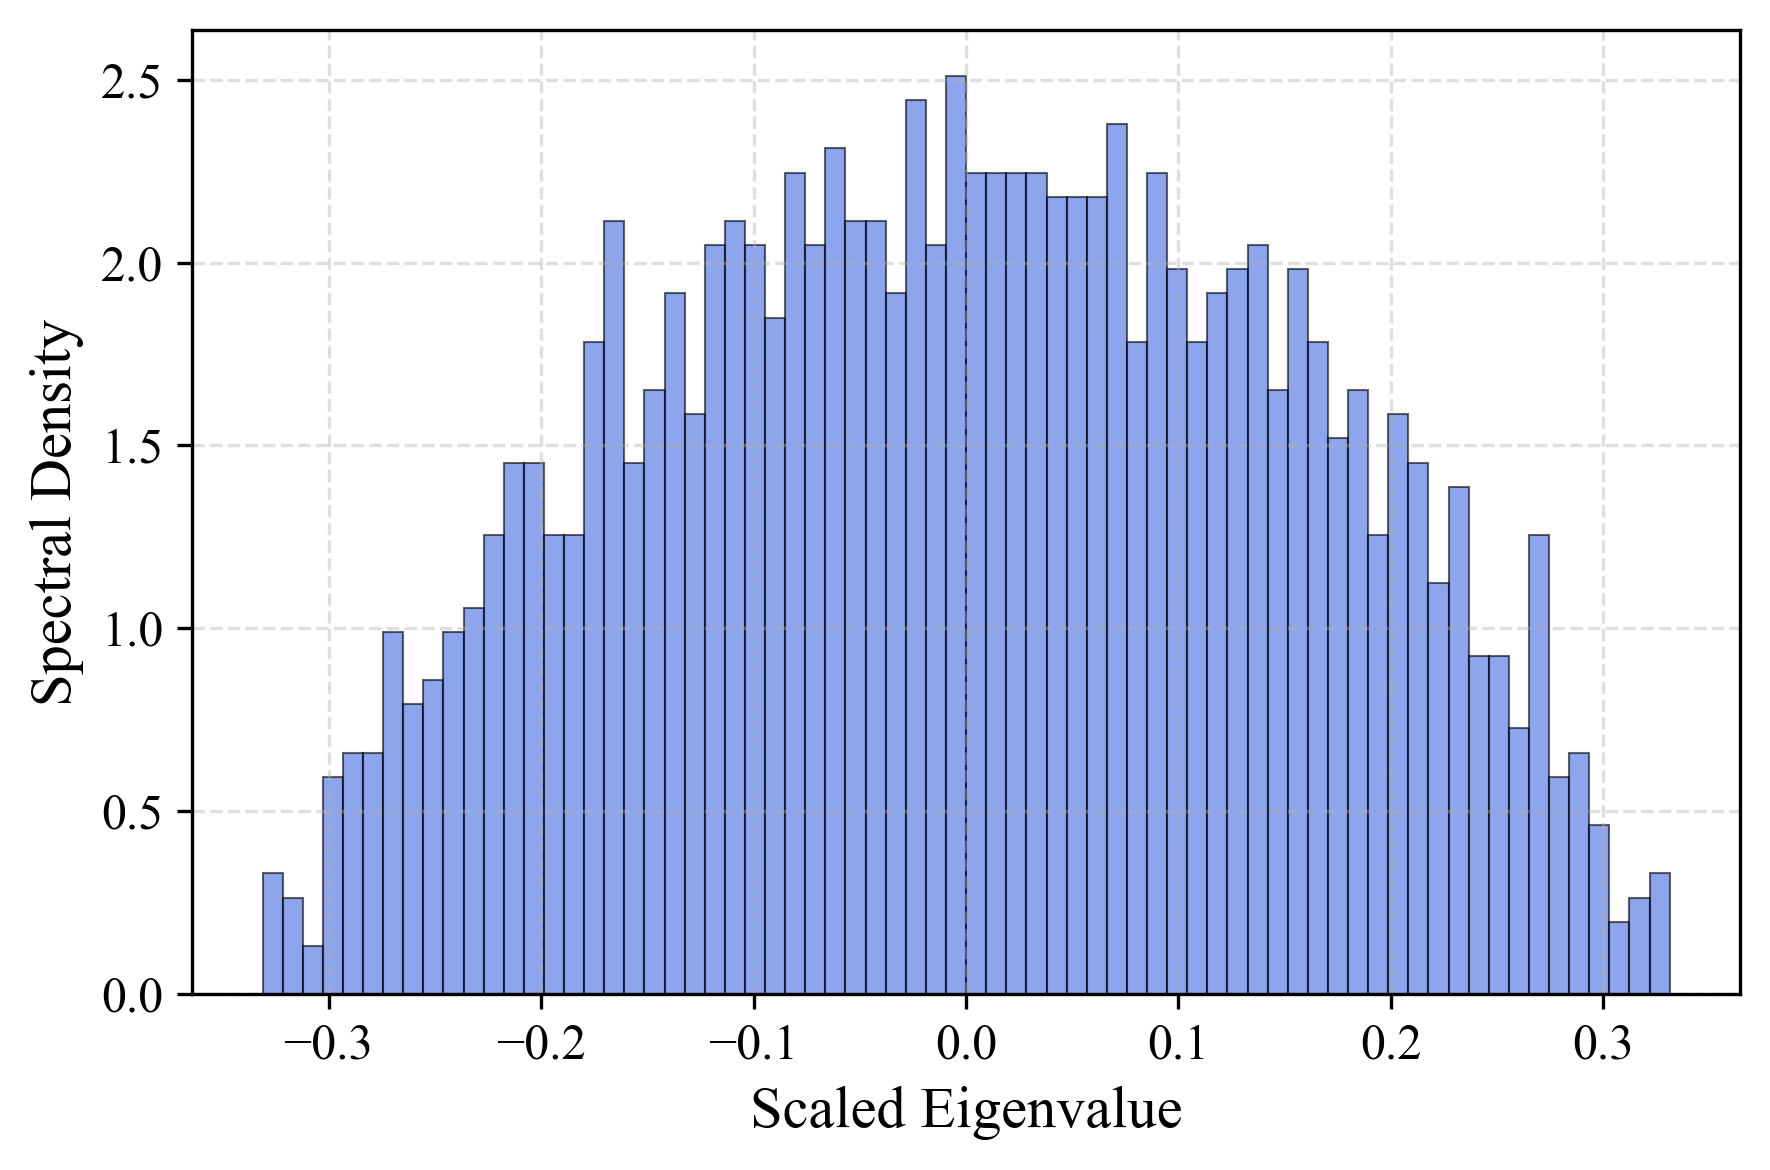


Processing ../results/run_20251215_1334/S_runs_10.pkl, containing 4 lambda indices...


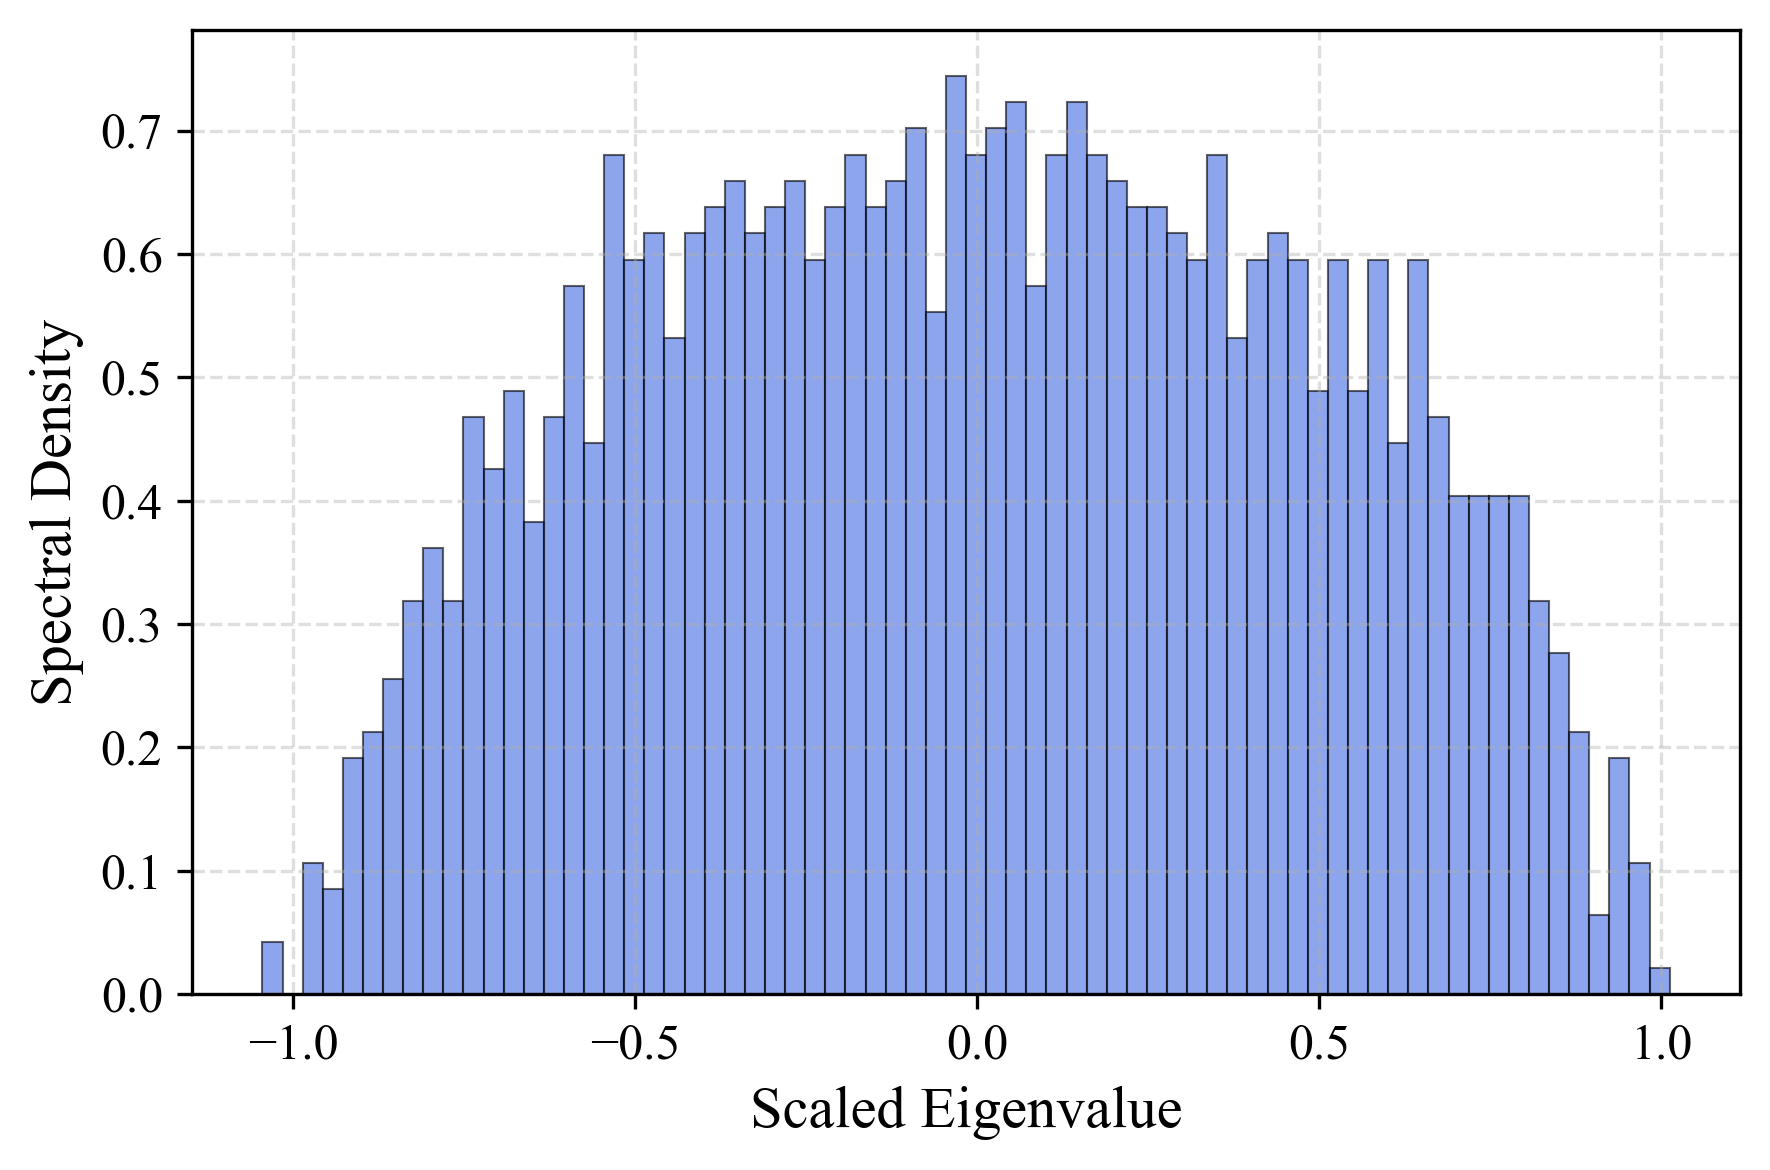


Processing ../results/run_20251215_1334/S_runs_11.pkl, containing 4 lambda indices...


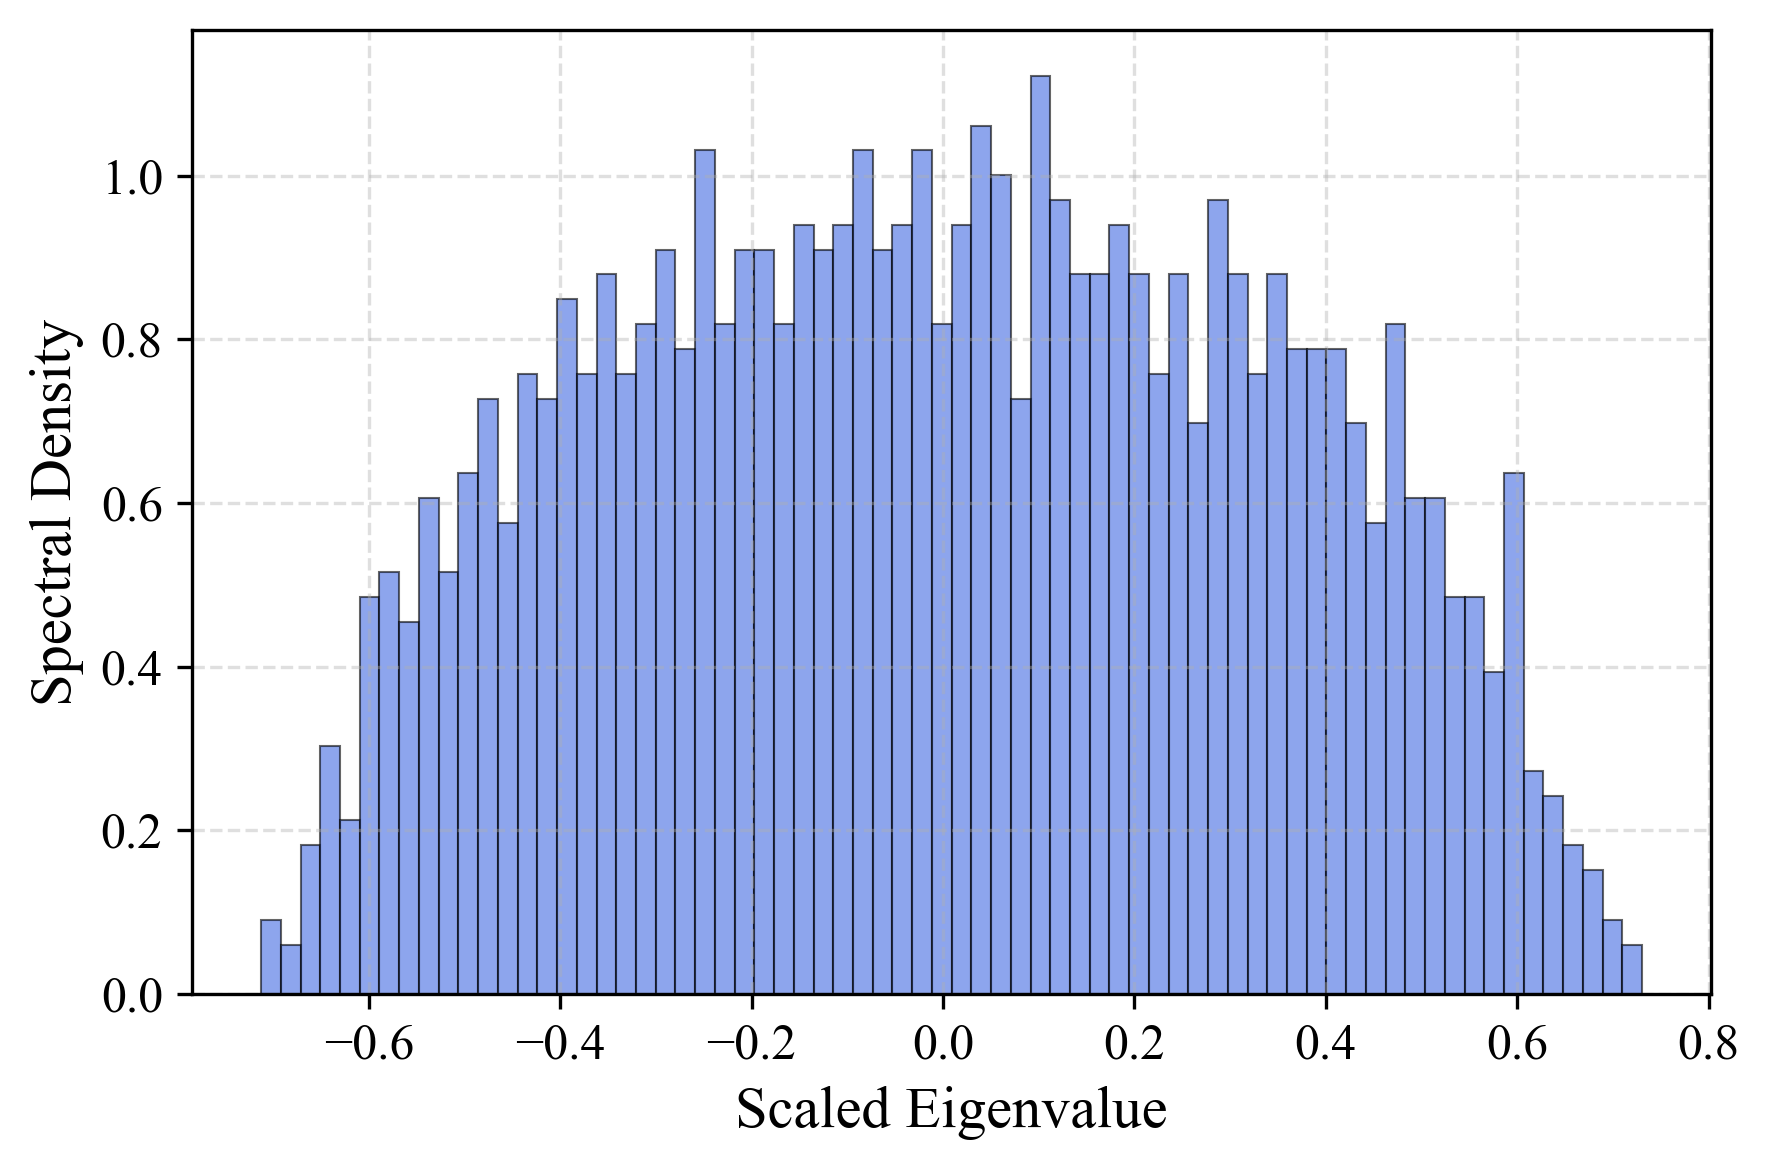


Processing ../results/run_20251215_1334/S_runs_12.pkl, containing 4 lambda indices...


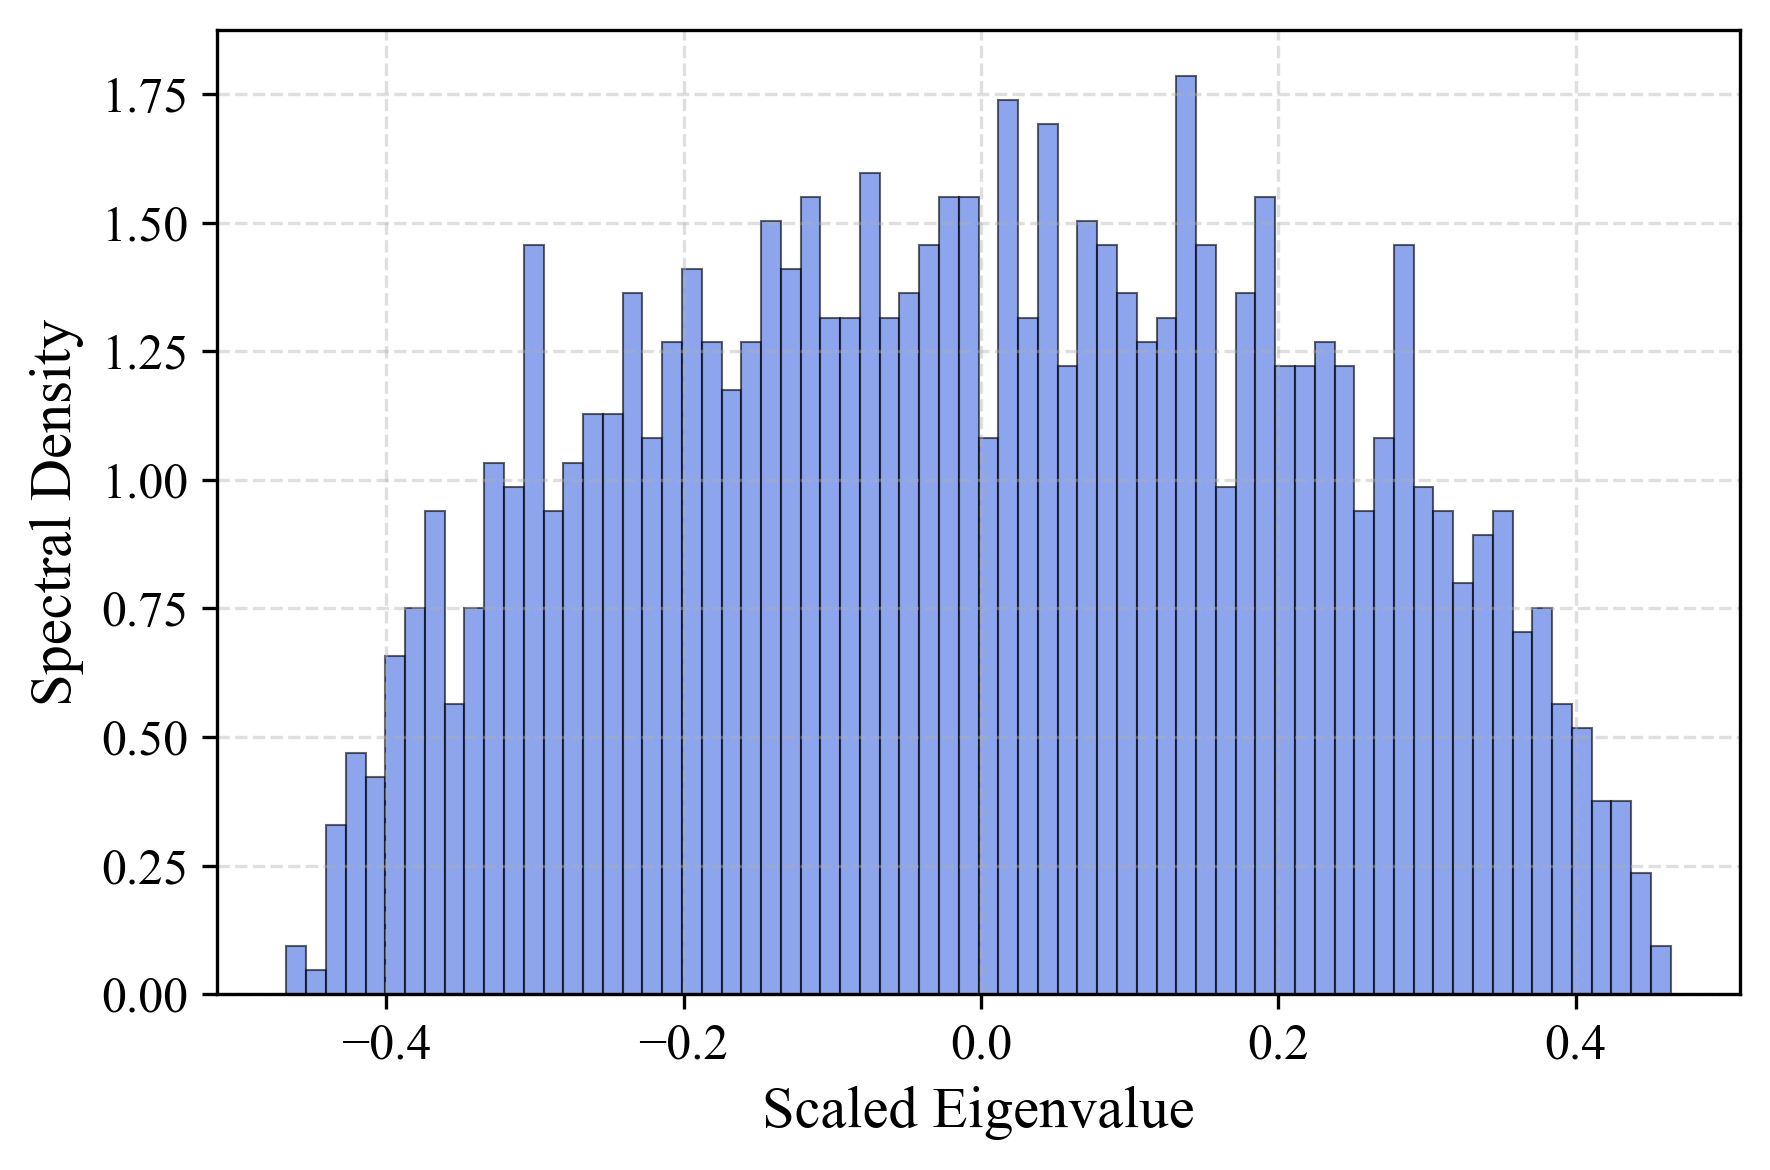


Processing ../results/run_20251215_1334/S_runs_13.pkl, containing 4 lambda indices...


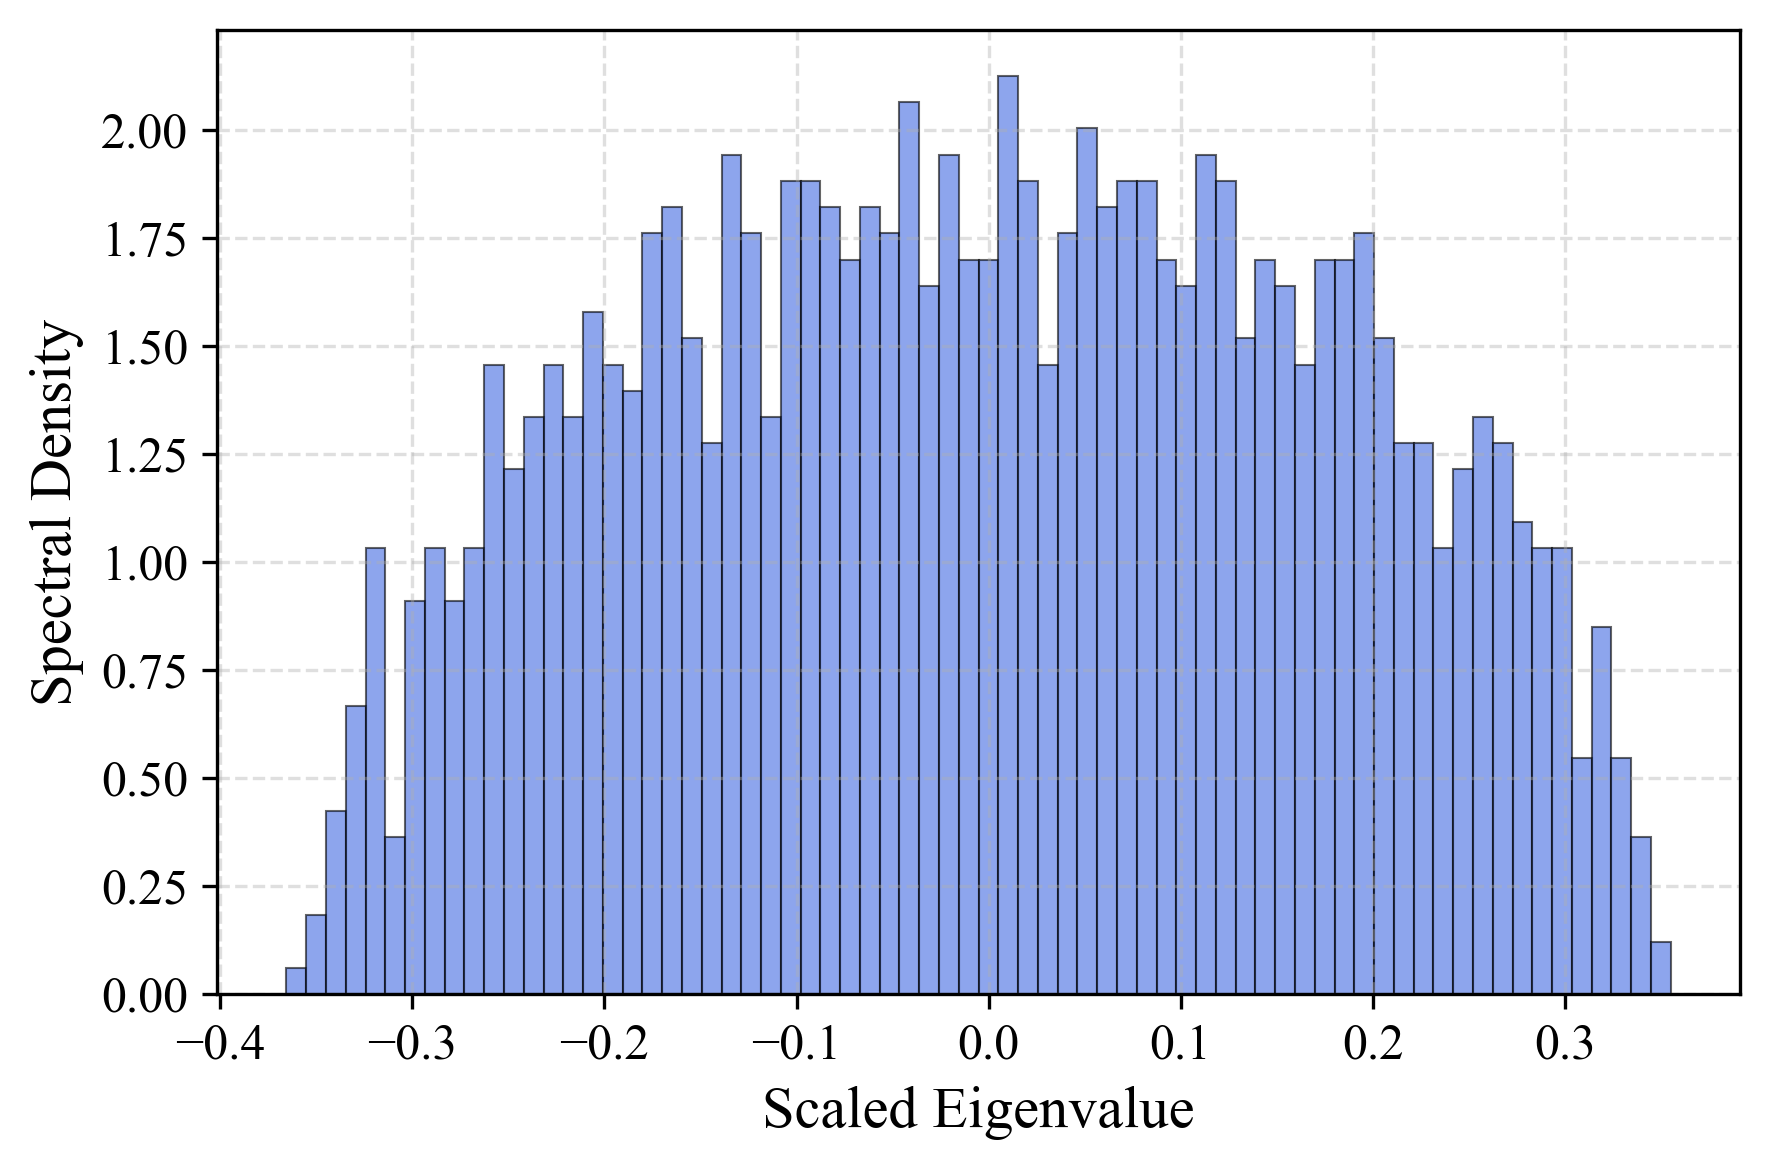


Processing ../results/run_20251215_1334/S_runs_14.pkl, containing 4 lambda indices...


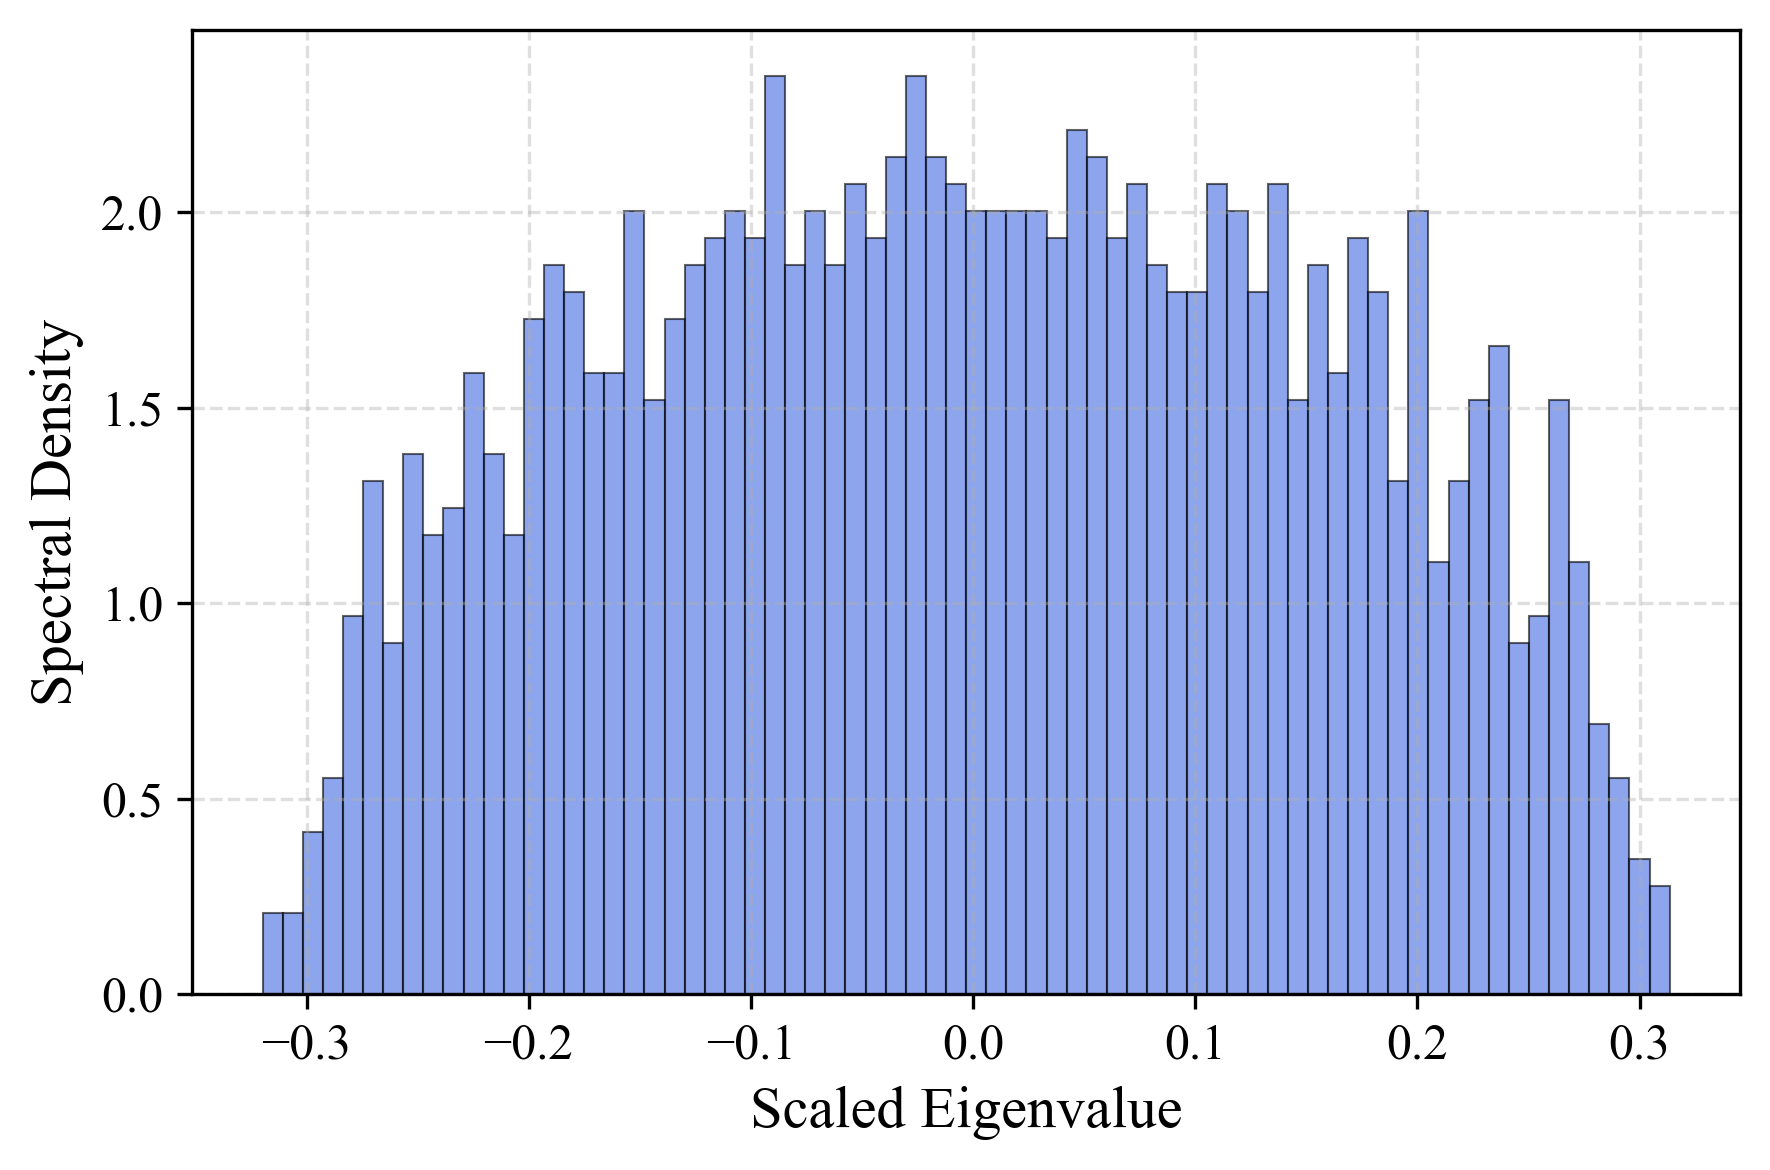


Processing ../results/run_20251215_1334/S_runs_2.pkl, containing 4 lambda indices...


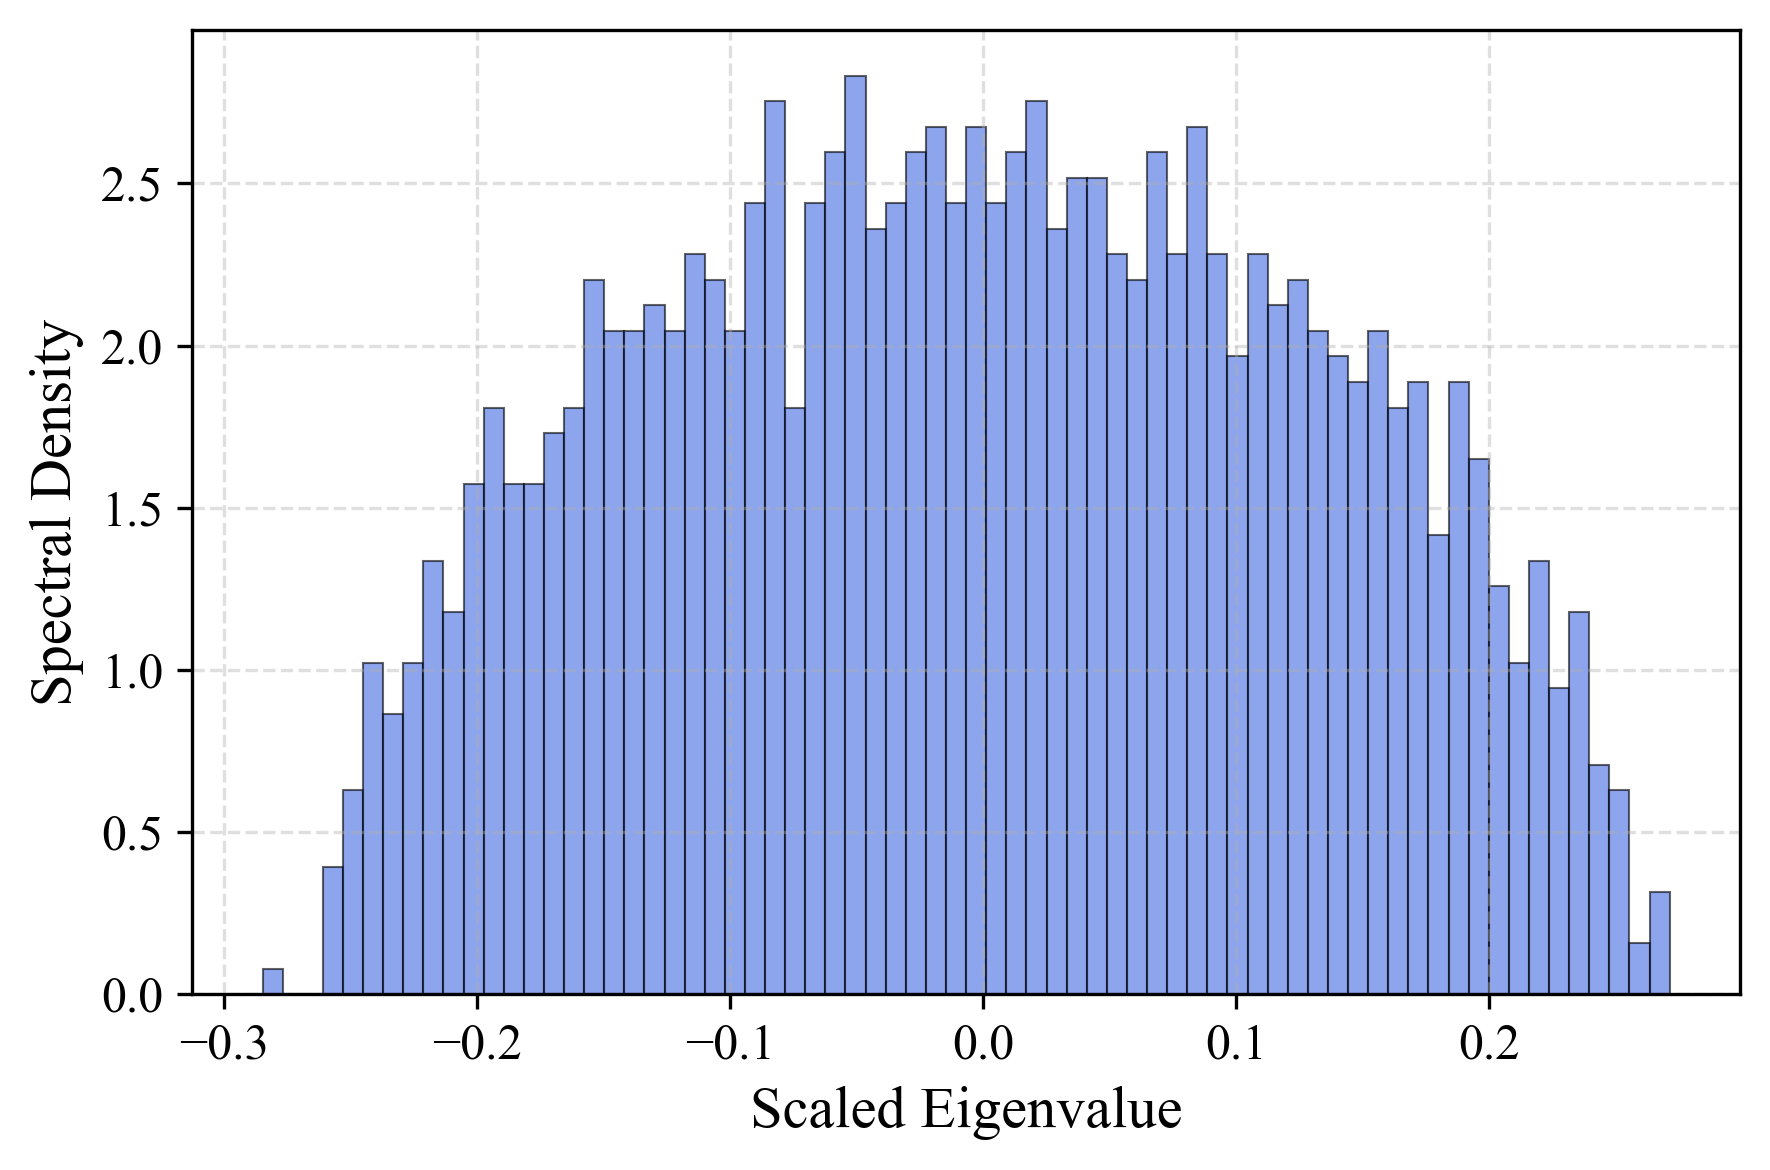


Processing ../results/run_20251215_1334/S_runs_3.pkl, containing 4 lambda indices...


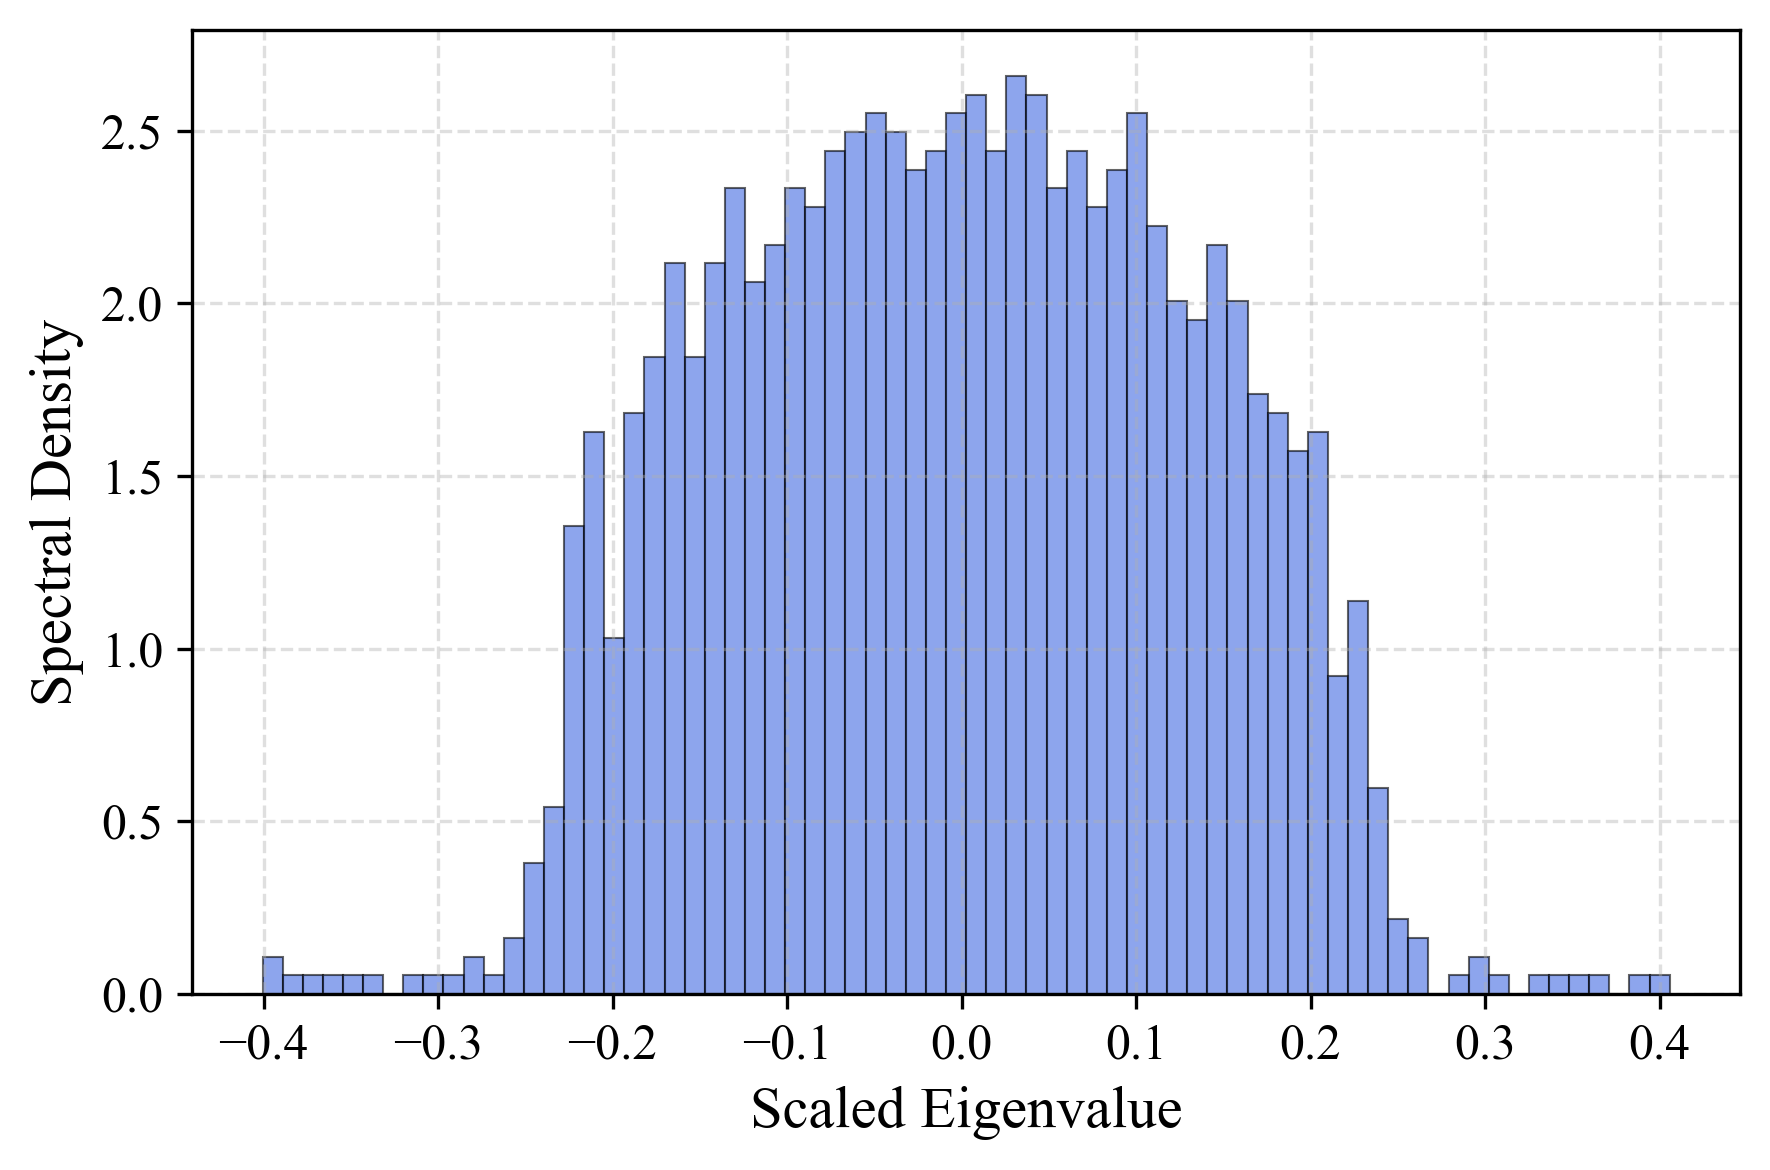


Processing ../results/run_20251215_1334/S_runs_4.pkl, containing 4 lambda indices...


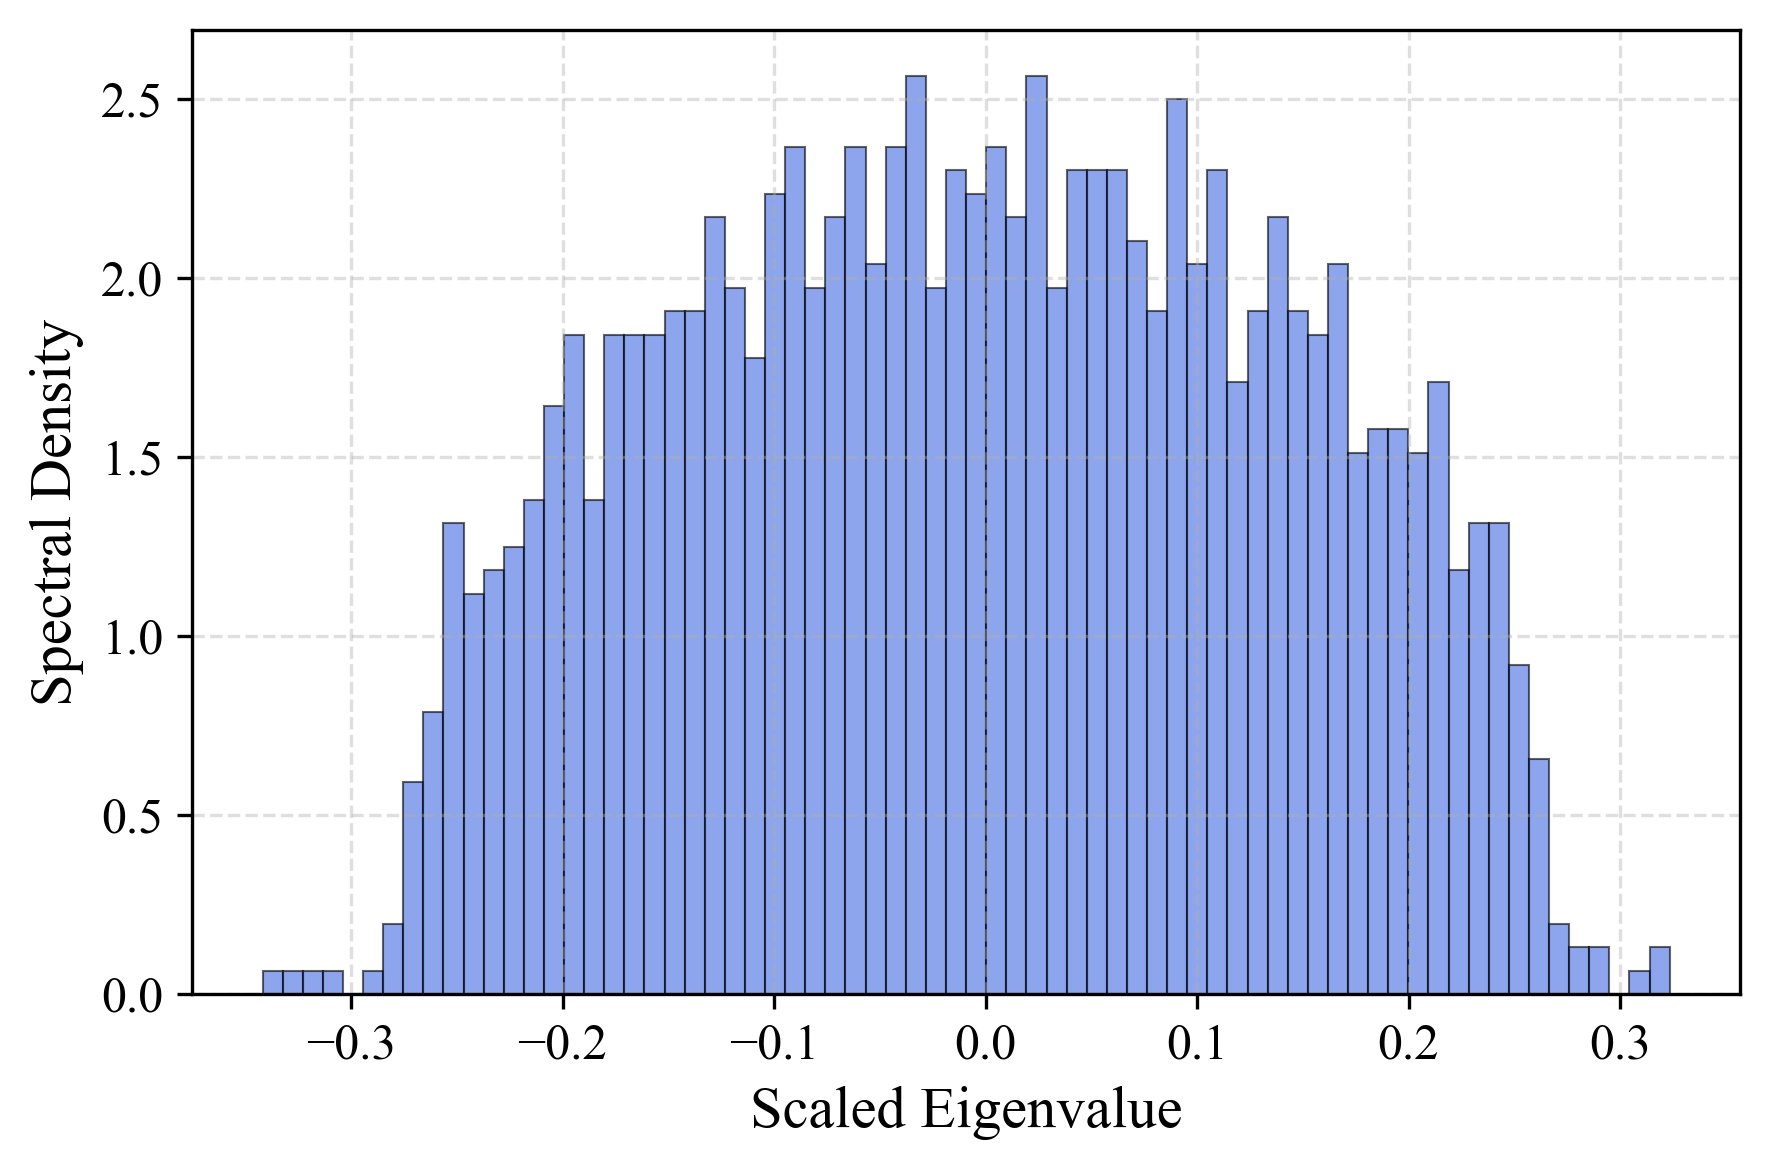


Processing ../results/run_20251215_1334/S_runs_5.pkl, containing 4 lambda indices...


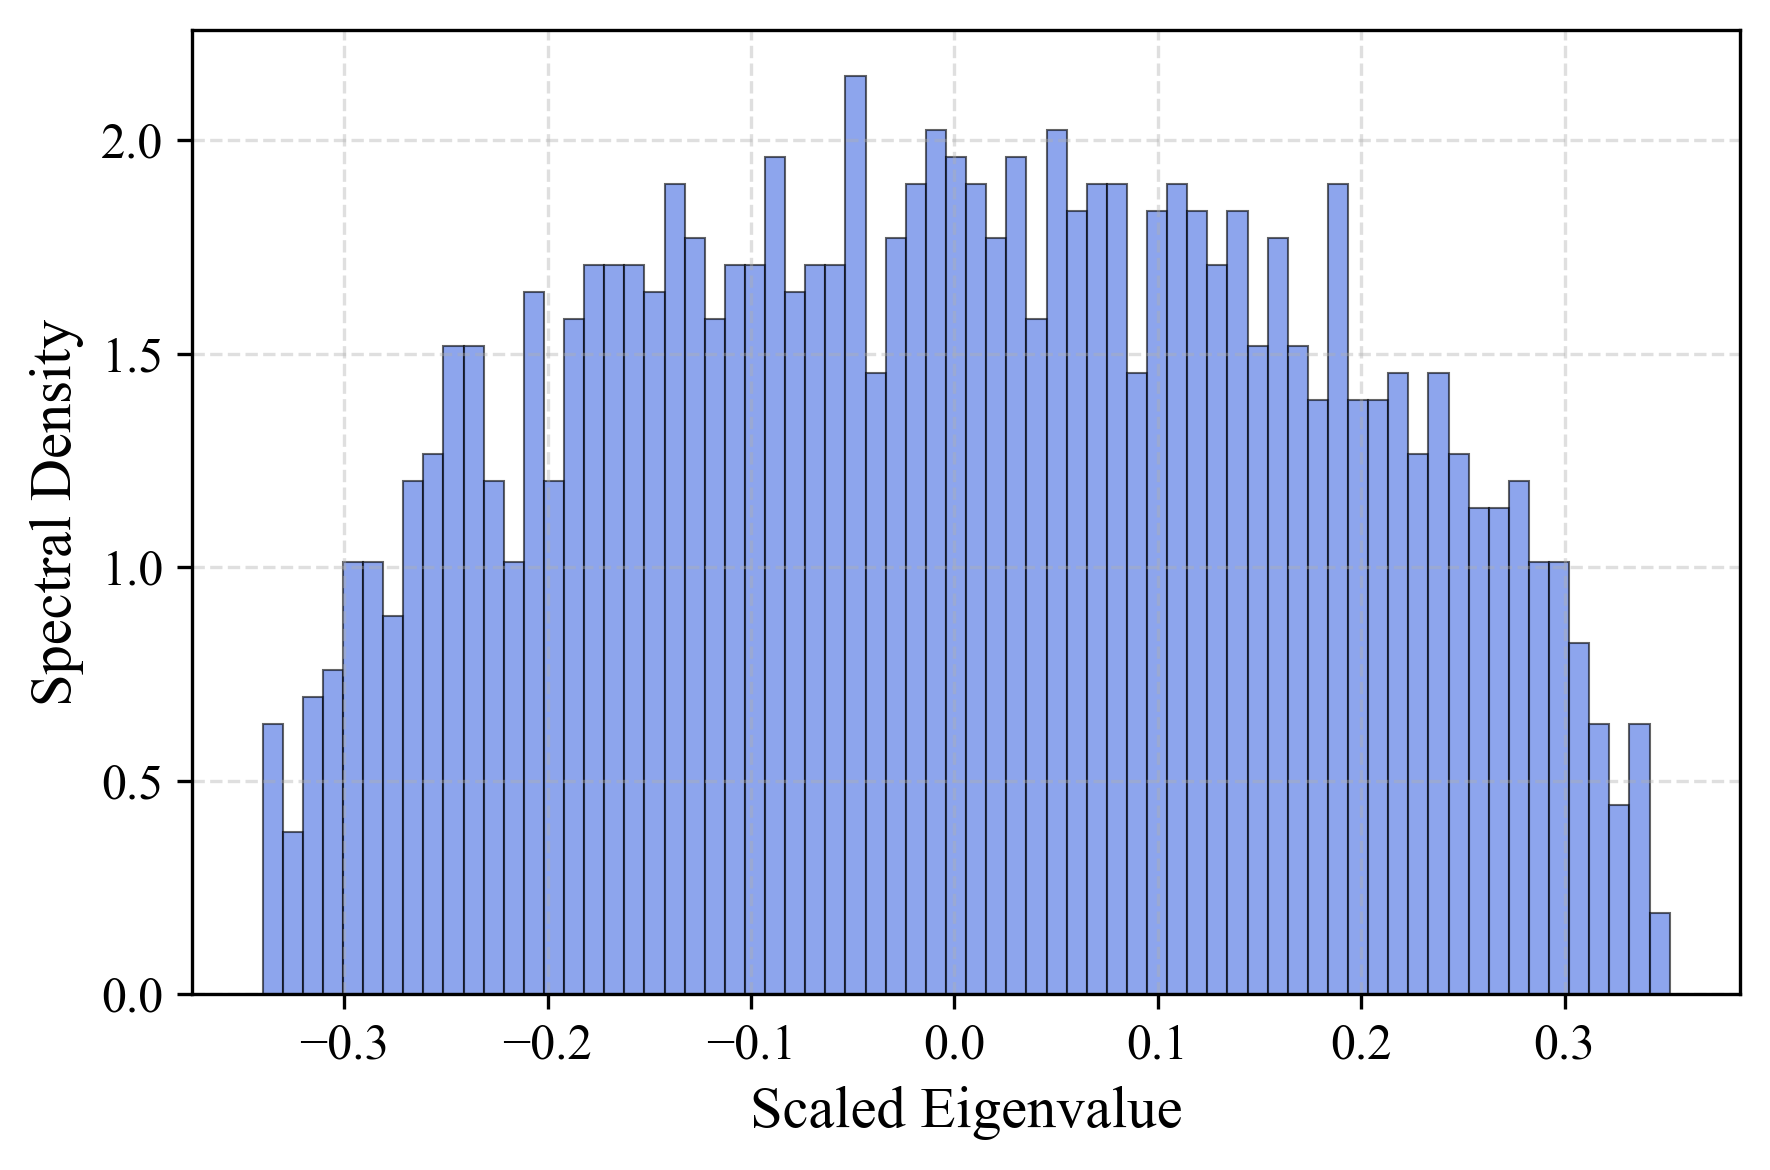


Processing ../results/run_20251215_1334/S_runs_6.pkl, containing 4 lambda indices...


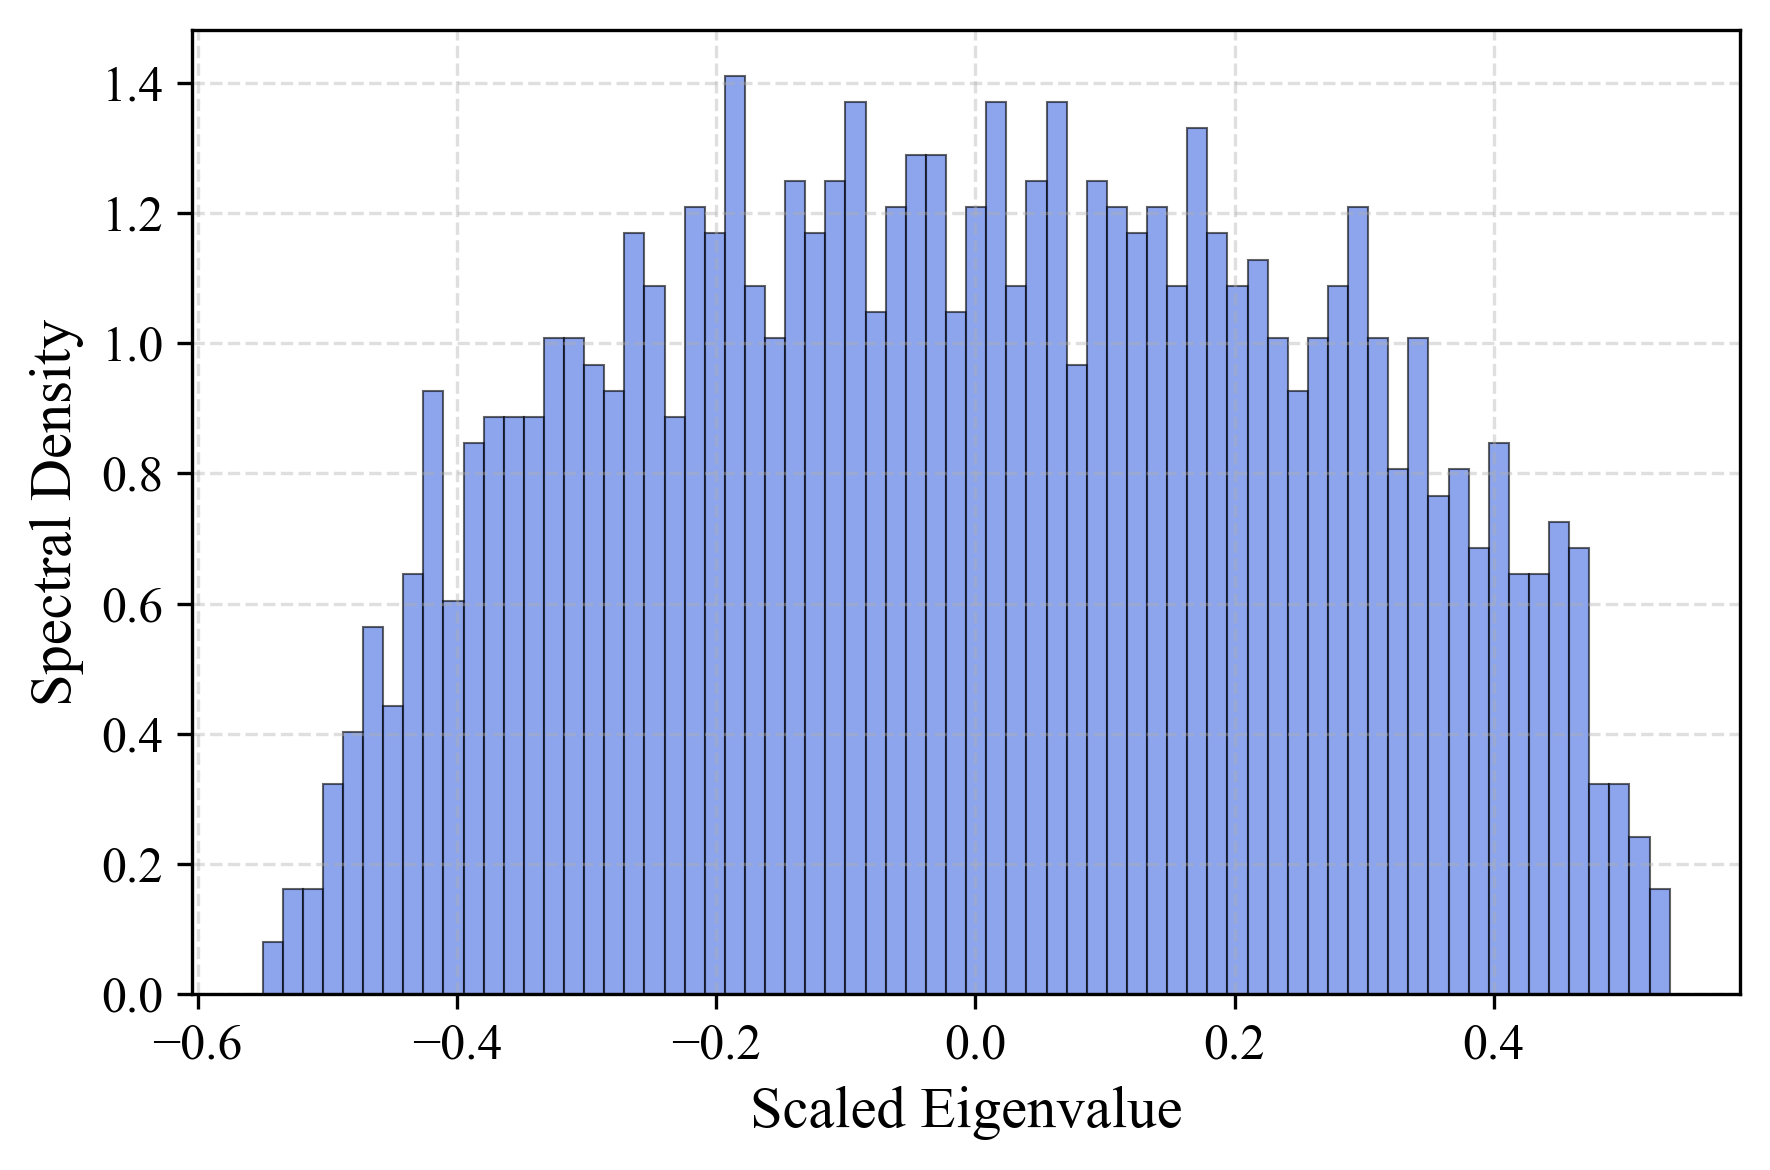


Processing ../results/run_20251215_1334/S_runs_7.pkl, containing 4 lambda indices...


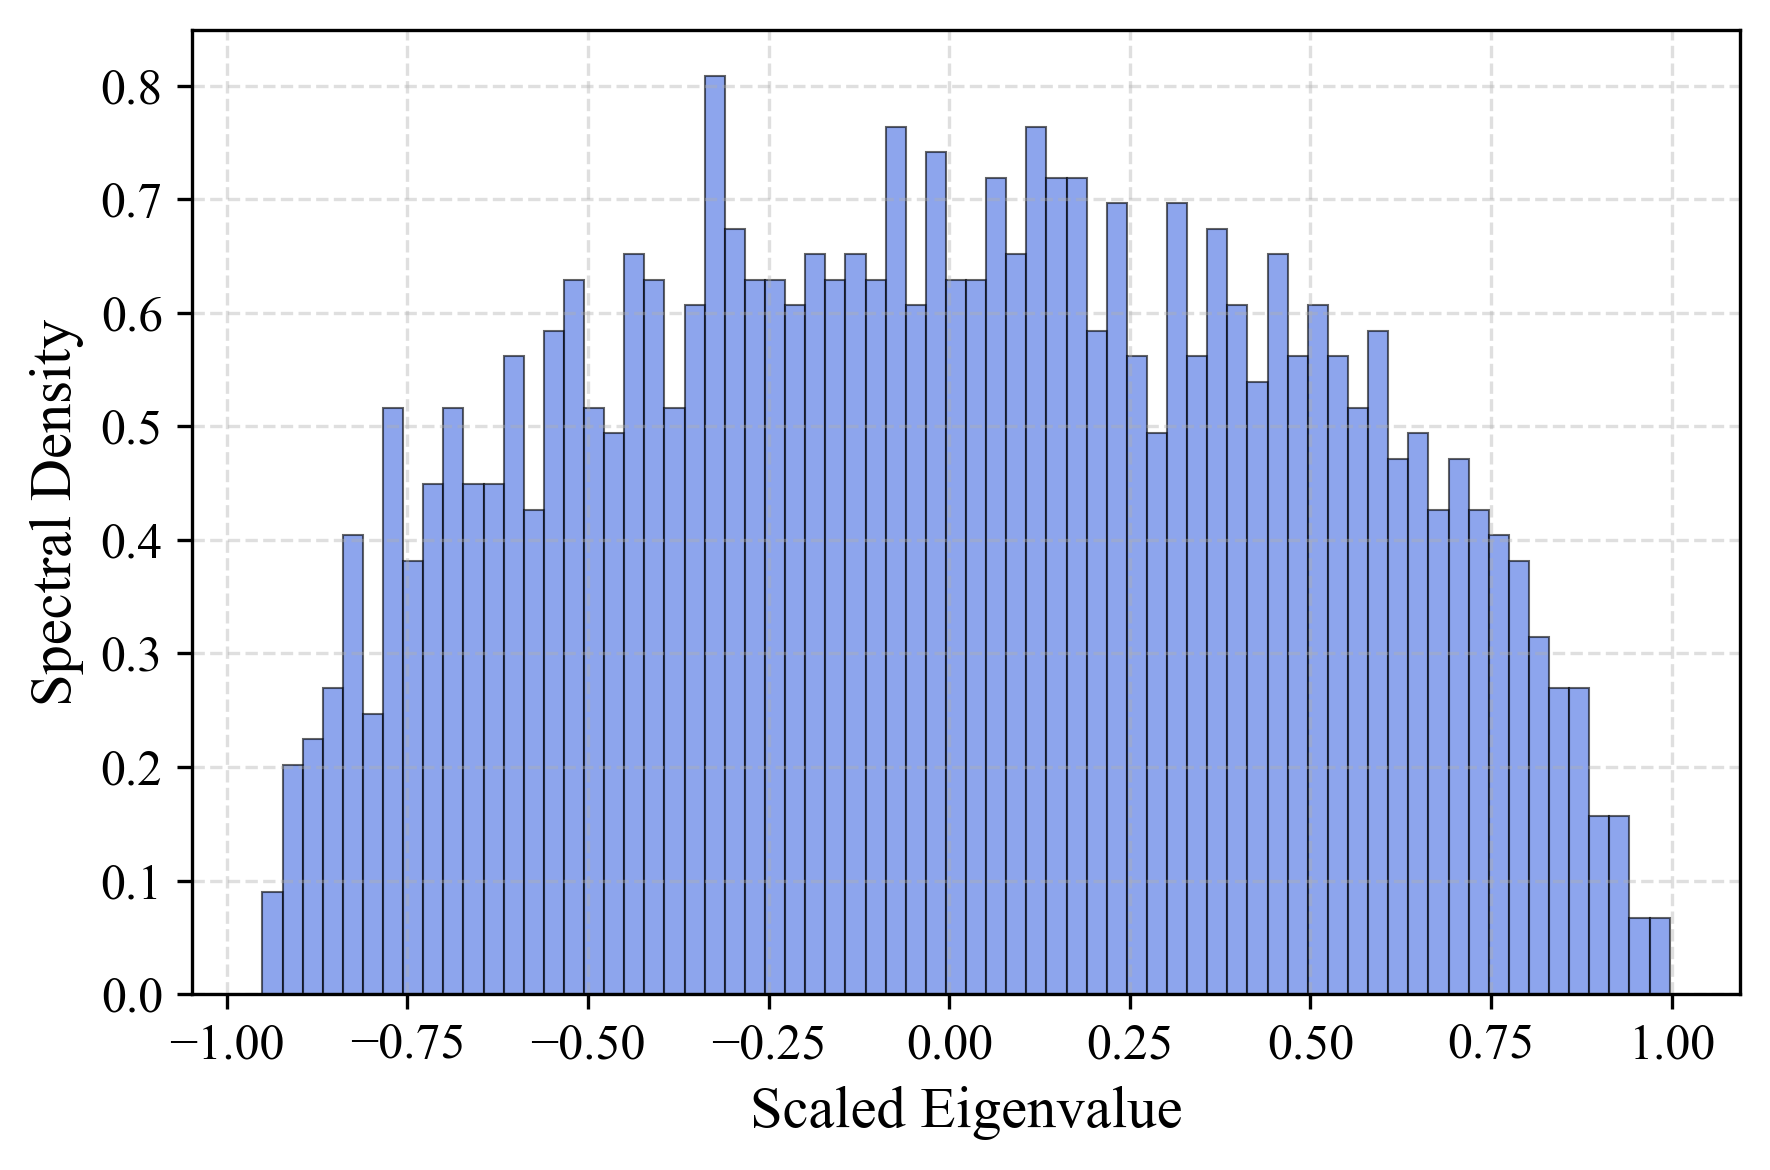


Processing ../results/run_20251215_1334/S_runs_8.pkl, containing 4 lambda indices...


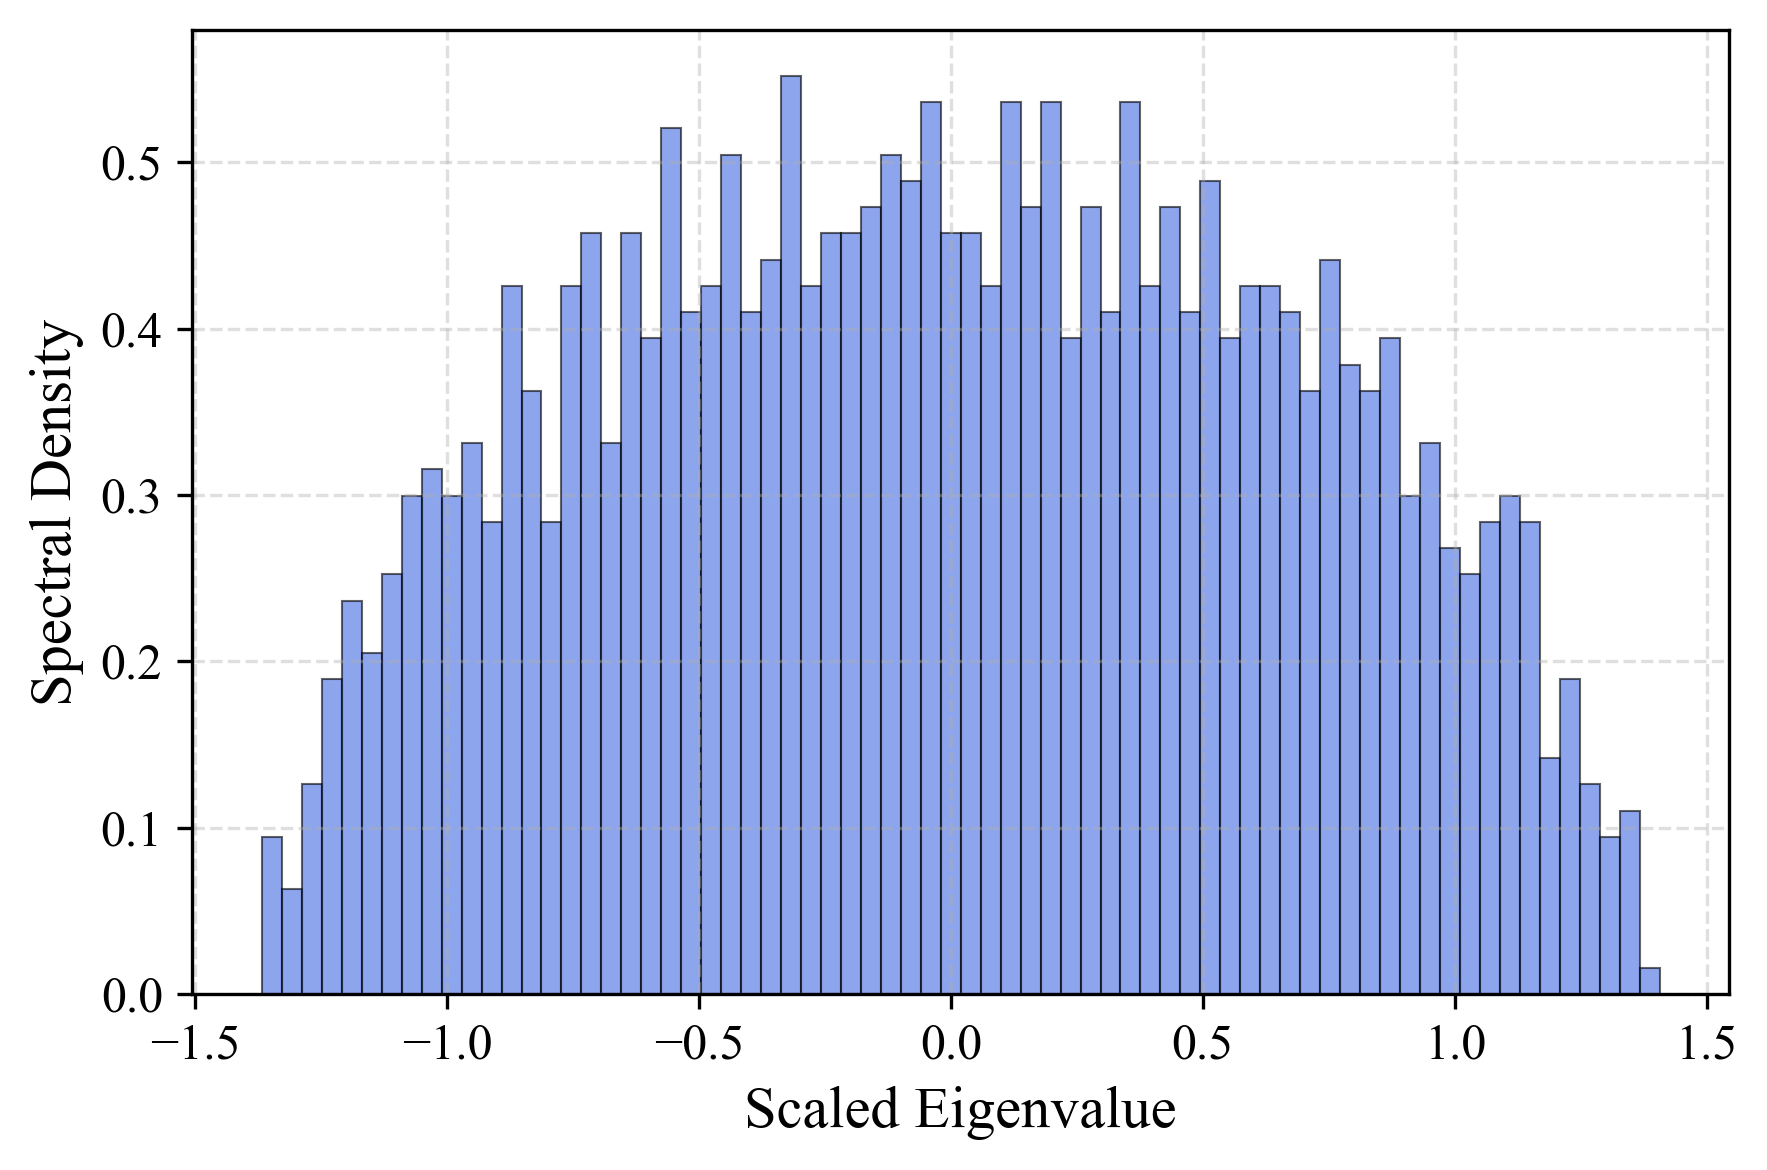


Processing ../results/run_20251215_1334/S_runs_9.pkl, containing 4 lambda indices...


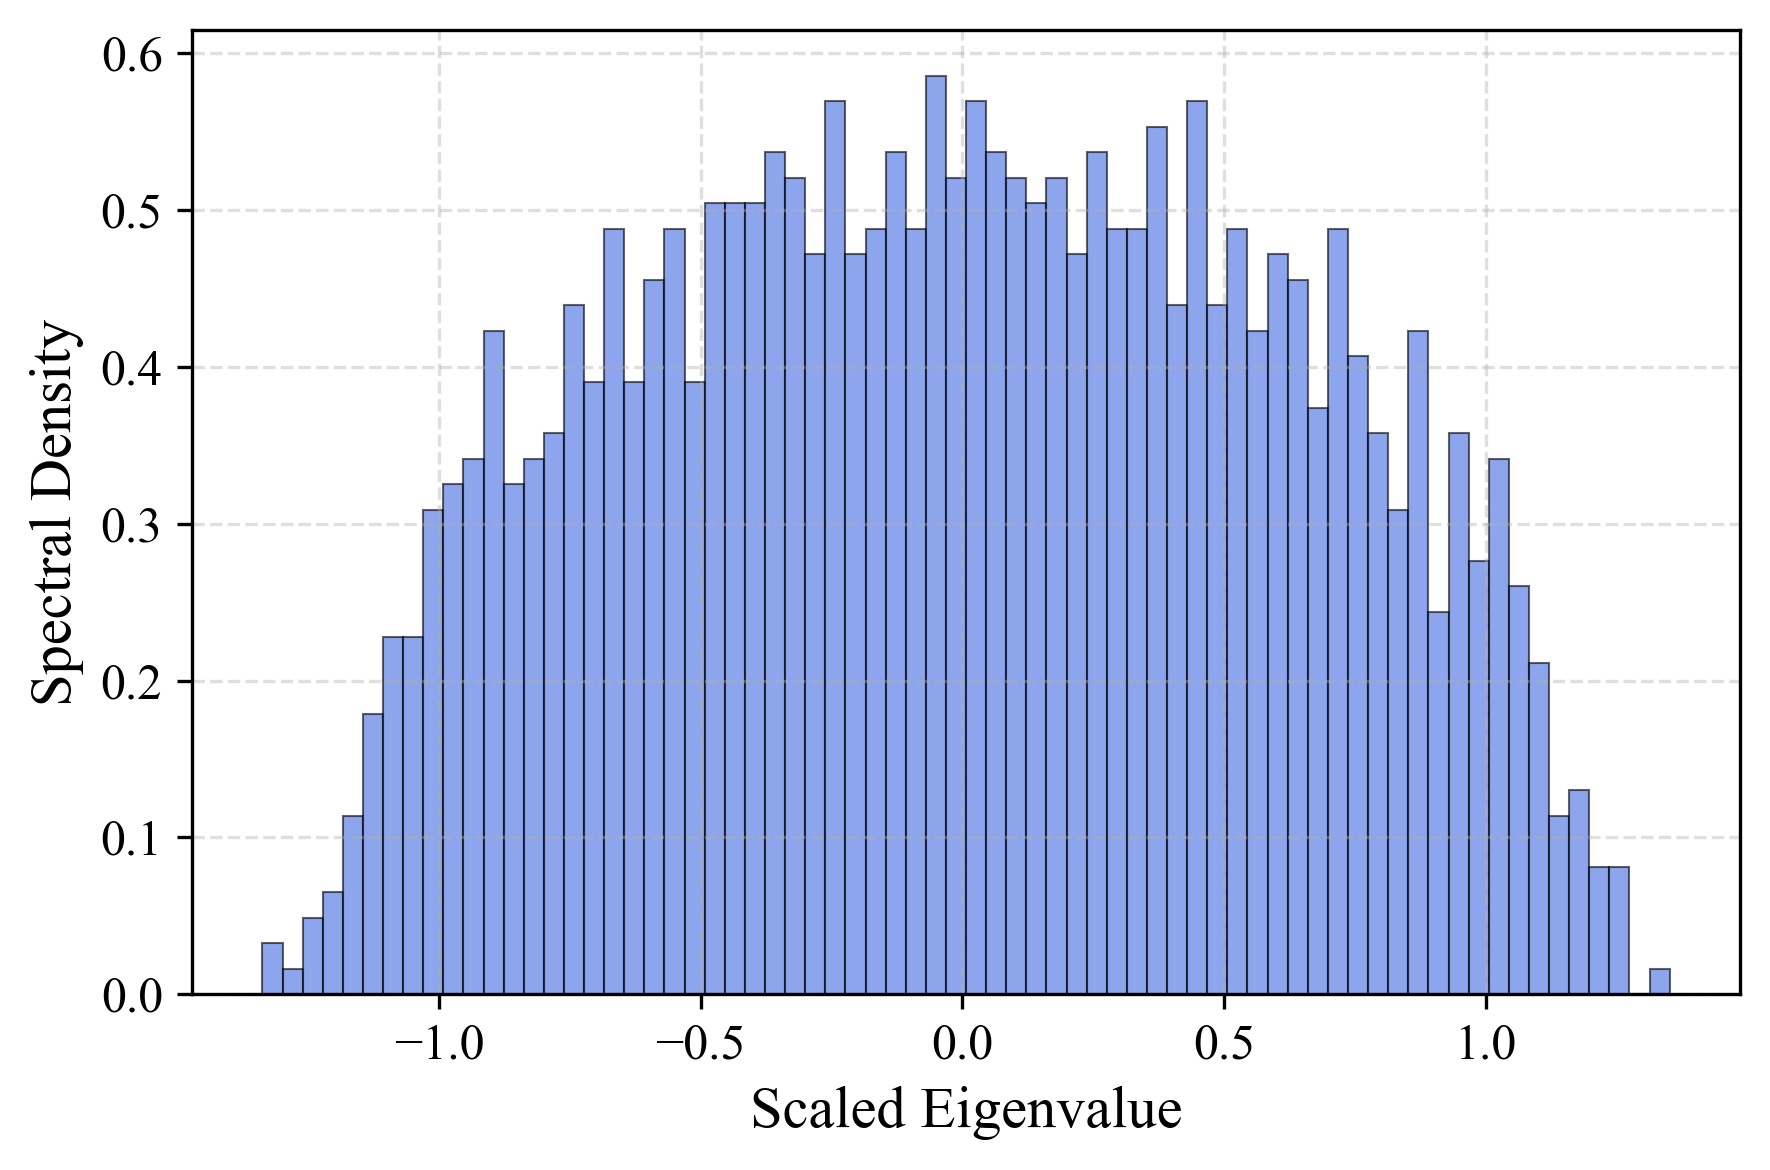

In [34]:
# --- Choose lambda index to plot ---
lambda_index = 3   # <<< change me

D = config.D[0] # normalization factor for singular values

# --- Path to your results directory ---
run_dir = f"../results/run_{run_id}"
pkl_files = sorted(glob.glob(os.path.join(run_dir, "S_runs_*.pkl")))

print(f"Found {len(pkl_files)} S_runs files.")

# --- Loop over pickle files ---
for pkl_file in pkl_files:
    with open(pkl_file, "rb") as f:
        S_runs_all = pickle.load(f)  # list over λ; each element is list over α

    print(f"\nProcessing {pkl_file}, containing {len(S_runs_all)} lambda indices...")

    # --- Check lambda index ---
    if lambda_index >= len(S_runs_all):
        print(f"lambda_index {lambda_index} out of range for this file, skipping.")
        continue

    # --- Extract all eigenvalues for this λ ---
    S_list = S_runs_all[lambda_index]

    all_eigvals = []
    for S in S_list:
        eigvals = np.linalg.eigvalsh(S)
        all_eigvals.extend(eigvals)

    all_eigvals = np.array(all_eigvals)

    # --- Plot ---
    plt.figure(figsize=(6, 4))
    plt.hist(all_eigvals/np.sqrt(D), bins=70, alpha=0.6, linewidth=0.5, edgecolor='black', color='royalblue', density=True)

    plt.xlabel("Scaled Eigenvalue")
    plt.ylabel("Spectral Density")
    # plt.title(f"Eigenvalue distribution — λ index {lambda_index}\n{os.path.basename(pkl_file)}")
    plt.grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()